<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/taller8OCTUBRE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Replace 'your_database.csv' with the actual path to your database file
try:
    df = pd.read_csv('weather_features.csv')
    print("Database loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: The file 'weather_features.csv' was not found. Please provide the correct path to your database file.")
except Exception as e:
    print(f"An error occurred: {e}")

Database loaded successfully!


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n


In [ ]:
# Extract the 'humidity' column
humidity_data = df['humidity']

# Display the humidity data
display(humidity_data)

,humidity
0,77.0
1,77.0
2,78.0
3,78.0
4,78.0
...,...
46810,45.0
46811,59.0
46812,63.0
46813,67.0


=== RESUMEN DEL FILTRADO ===
Frecuencia de muestreo fs = 1.0000 Hz
Frecuencia de corte fc = 0.0100 Hz
Orden del filtro = 4
SNR añadido = 20.0 dB
Coeficientes b: [ 0.921171 -3.684684  5.527026 -3.684684  0.921171]
Coeficientes a: [ 1.       -3.835826  5.520819 -3.533535  0.848556]


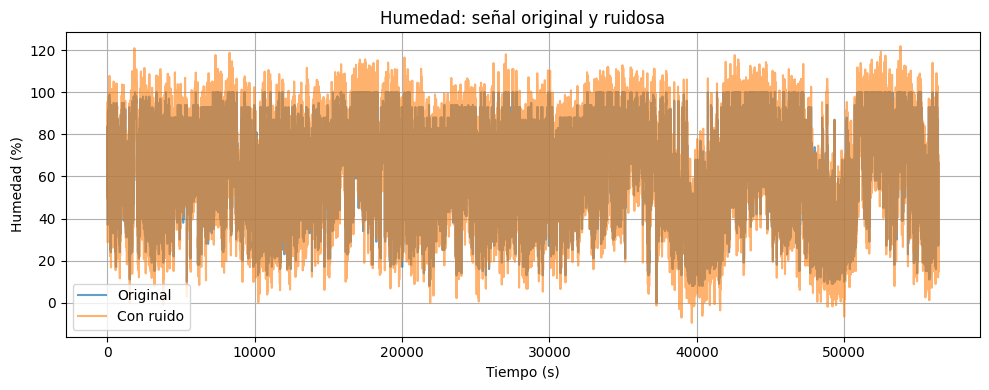

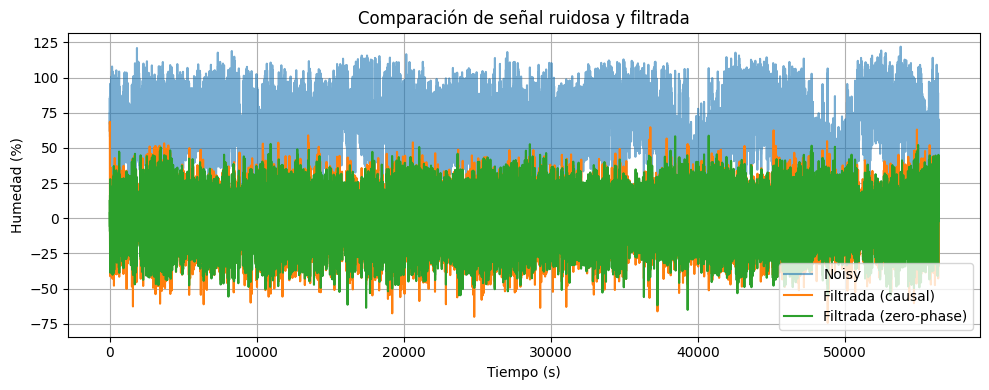

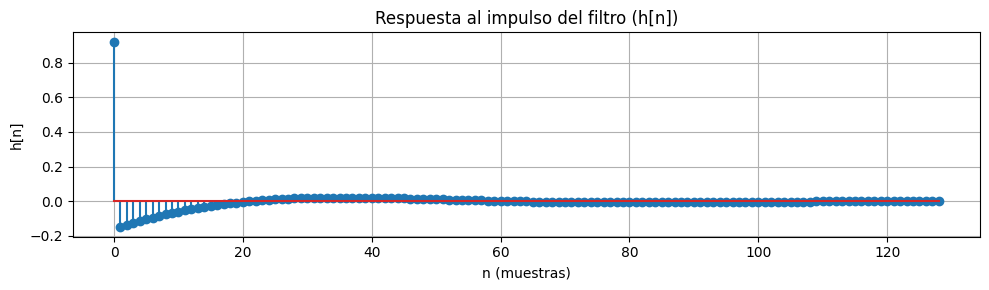

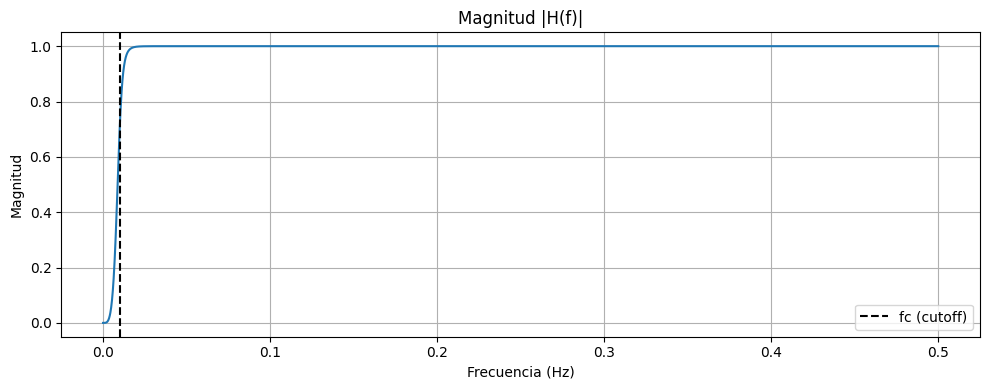

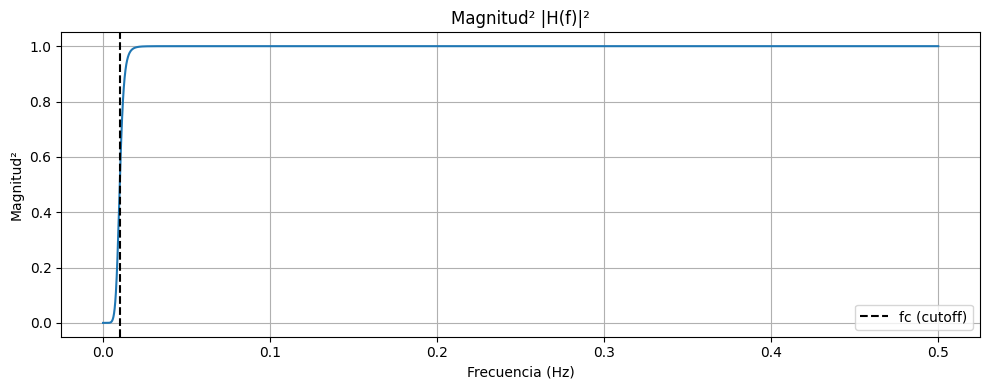

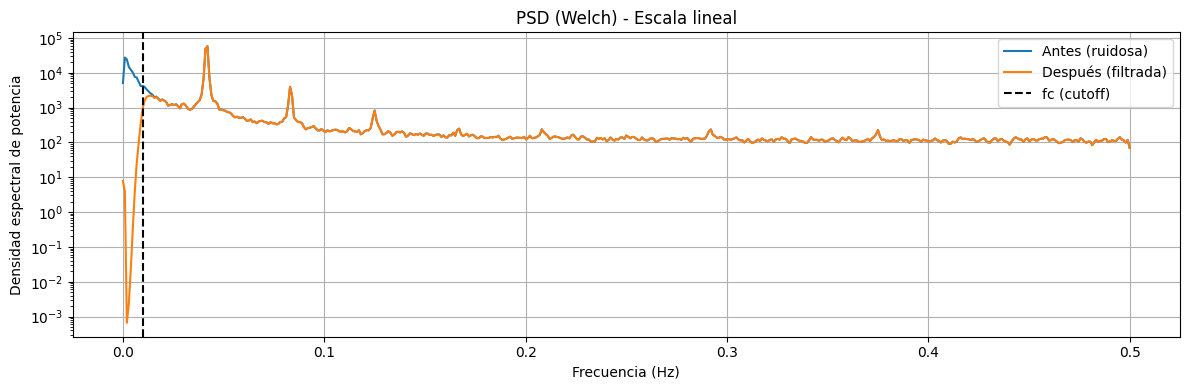

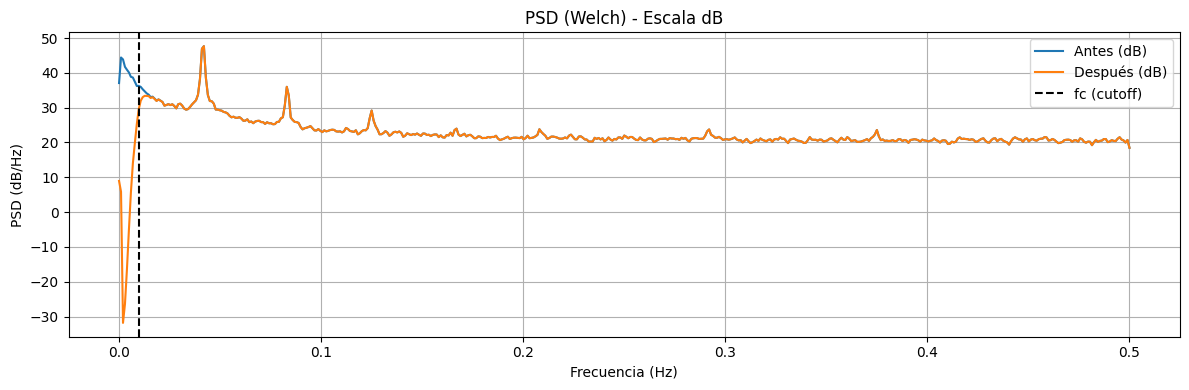

In [ ]:
# === FILTRO PASA ALTAS A SEÑAL DE HUMEDAD ===
# Incluye: carga de datos, ruido blanco, diseño Butterworth digital realizable,
# función de transferencia, magnitud, |H(f)|² y espectro de potencia (PSD).

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# === Parámetros ajustables ===
filename = "weather_features.csv"  # Nombre del archivo
filter_order = 4                   # Orden del filtro Butterworth
snr_db = 20.0                      # Nivel de ruido blanco (dB)
cutoff_hz = None                   # Frecuencia de corte (None = 0.01 * fs)

# === Cargar base de datos ===
if not os.path.exists(filename):
    raise FileNotFoundError(f"Archivo '{filename}' no encontrado. Súbelo al entorno.")

df = pd.read_csv(filename)

# Buscar columna de humedad (case-insensitive)
humidity_col = None
for col in df.columns:
    if col.lower() == "humidity" or "humid" in col.lower():
        humidity_col = col
        break
if humidity_col is None:
    raise ValueError("No se encontró columna de humedad en el CSV.")

hum_series = df[humidity_col].copy()

# Intentar detectar frecuencia de muestreo si hay tiempo
fs = 1.0
time_col = None
for col in df.columns:
    if "time" in col.lower() or "date" in col.lower() or "timestamp" in col.lower():
        time_col = col
        break

if time_col is not None:
    try:
        times = pd.to_datetime(df[time_col])
        deltas = times.diff().dt.total_seconds().dropna()
        if len(deltas) > 0 and (deltas > 0).all():
            fs = 1.0 / deltas.median()
            time_seconds = (times - times.iloc[0]).dt.total_seconds().values
        else:
            time_col = None
    except Exception:
        time_col = None

if time_col is None:
    time_seconds = np.arange(len(hum_series)).astype(float)
    fs = 1.0

# Limpiar NaN e interpolar
hum = pd.to_numeric(hum_series, errors="coerce")
hum = hum.interpolate(limit_direction="both").fillna(method="bfill").fillna(method="ffill").values.astype(float)

# Determinar frecuencia de corte
if cutoff_hz is None:
    cutoff_hz = 0.01 * fs
if not (0 < cutoff_hz < fs / 2):
    raise ValueError(f"Frecuencia de corte inválida. fs={fs}, fc={cutoff_hz}")

# Añadir ruido blanco gaussiano
sig_power = np.mean(hum ** 2)
snr_linear = 10 ** (snr_db / 10)
noise_power = sig_power / snr_linear
rng = np.random.default_rng(12345)
noise = rng.normal(scale=np.sqrt(noise_power), size=hum.shape)
hum_noisy = hum + noise

# === Filtro Butterworth pasa altas ===
nyq = fs / 2
Wn = cutoff_hz / nyq
b, a = signal.butter(filter_order, Wn, btype="high", analog=False, output="ba")

# Filtrado causal y cero fase
hum_filtered_causal = signal.lfilter(b, a, hum_noisy)
hum_filtered_zero_phase = signal.filtfilt(b, a, hum_noisy)

# === Respuesta al impulso ===
h_imp = signal.lfilter(b, a, np.concatenate(([1.0], np.zeros(128))))

# === Respuesta en frecuencia ===
w, h_resp = signal.freqz(b, a, worN=4096, fs=fs)
magnitude = np.abs(h_resp)
magnitude_sq = magnitude ** 2

# === PSD (Welch) ===
nperseg = min(1024, max(256, len(hum) // 8))
f_orig, Pxx_orig = signal.welch(hum_noisy, fs=fs, nperseg=nperseg)
f_filt, Pxx_filt = signal.welch(hum_filtered_zero_phase, fs=fs, nperseg=nperseg)

# === Información ===
print("=== RESUMEN DEL FILTRADO ===")
print(f"Frecuencia de muestreo fs = {fs:.4f} Hz")
print(f"Frecuencia de corte fc = {cutoff_hz:.4f} Hz")
print(f"Orden del filtro = {filter_order}")
print(f"SNR añadido = {snr_db} dB")
print("Coeficientes b:", np.round(b, 6))
print("Coeficientes a:", np.round(a, 6))

# === GRAFICAR ===

# Señales original, ruidosa y filtrada
plt.figure(figsize=(10, 4))
plt.plot(time_seconds, hum, label="Original", alpha=0.7)
plt.plot(time_seconds, hum_noisy, label="Con ruido", alpha=0.6)
plt.title("Humedad: señal original y ruidosa")
plt.xlabel("Tiempo (s)")
plt.ylabel("Humedad (%)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_seconds, hum_noisy, label="Noisy", alpha=0.6)
plt.plot(time_seconds, hum_filtered_causal, label="Filtrada (causal)")
plt.plot(time_seconds, hum_filtered_zero_phase, label="Filtrada (zero-phase)")
plt.title("Comparación de señal ruidosa y filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Humedad (%)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Respuesta al impulso
plt.figure(figsize=(10, 3))
markerline, stemlines, baseline = plt.stem(np.arange(len(h_imp)), h_imp)
plt.setp(stemlines, 'linewidth', 1.5)
plt.title("Respuesta al impulso del filtro (h[n])")
plt.xlabel("n (muestras)")
plt.ylabel("h[n]")
plt.grid(True)
plt.tight_layout()
plt.show()

# Magnitud y magnitud²
plt.figure(figsize=(10, 4))
plt.plot(w, magnitude)
plt.axvline(cutoff_hz, color='k', linestyle='--', label='fc (cutoff)')
plt.title("Magnitud |H(f)|")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 4))
plt.plot(w, magnitude_sq)
plt.axvline(cutoff_hz, color='k', linestyle='--', label='fc (cutoff)')
plt.title("Magnitud² |H(f)|²")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud²")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# PSD - escala lineal
plt.figure(figsize=(12, 4))
plt.semilogy(f_orig, Pxx_orig, label="Antes (ruidosa)")
plt.semilogy(f_filt, Pxx_filt, label="Después (filtrada)")
plt.axvline(cutoff_hz, color='k', linestyle='--', label='fc (cutoff)')
plt.title("PSD (Welch) - Escala lineal")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Densidad espectral de potencia")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# PSD - escala dB
Pxx_orig_db = 10 * np.log10(np.maximum(Pxx_orig, 1e-18))
Pxx_filt_db = 10 * np.log10(np.maximum(Pxx_filt, 1e-18))

plt.figure(figsize=(12, 4))
plt.plot(f_orig, Pxx_orig_db, label="Antes (dB)")
plt.plot(f_filt, Pxx_filt_db, label="Después (dB)")
plt.axvline(cutoff_hz, color='k', linestyle='--', label='fc (cutoff)')
plt.title("PSD (Welch) - Escala dB")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD (dB/Hz)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


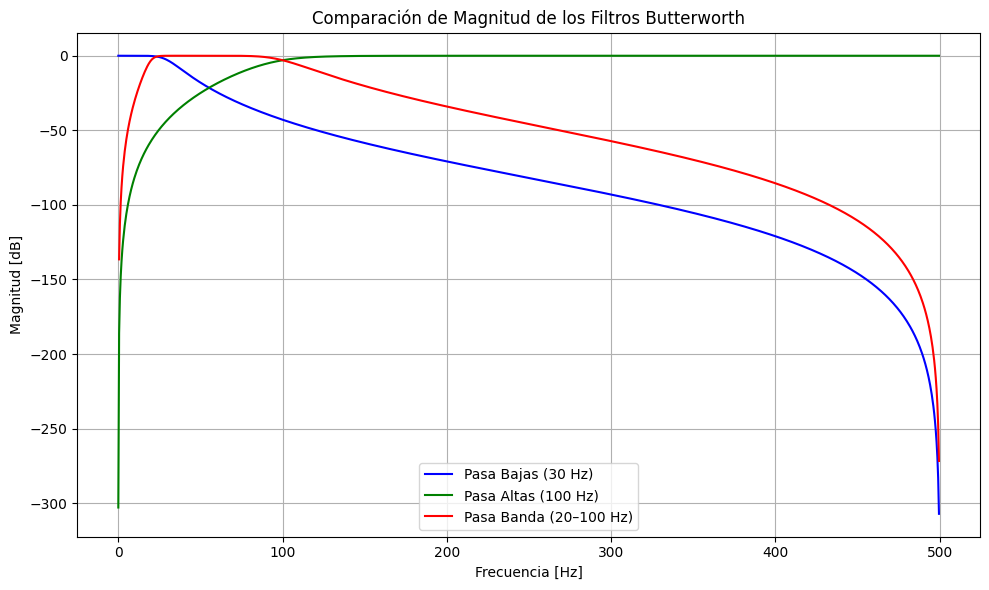

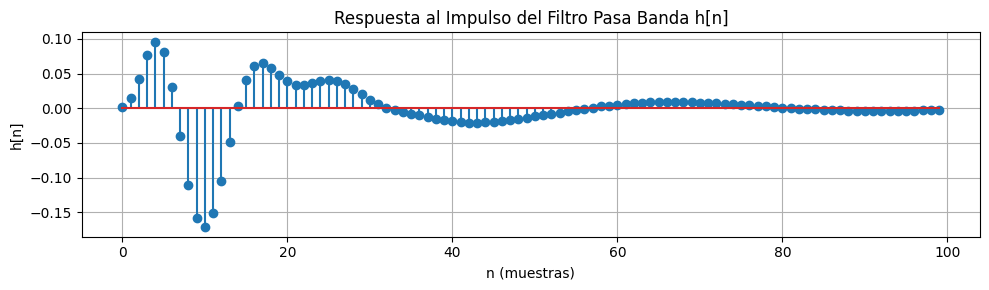

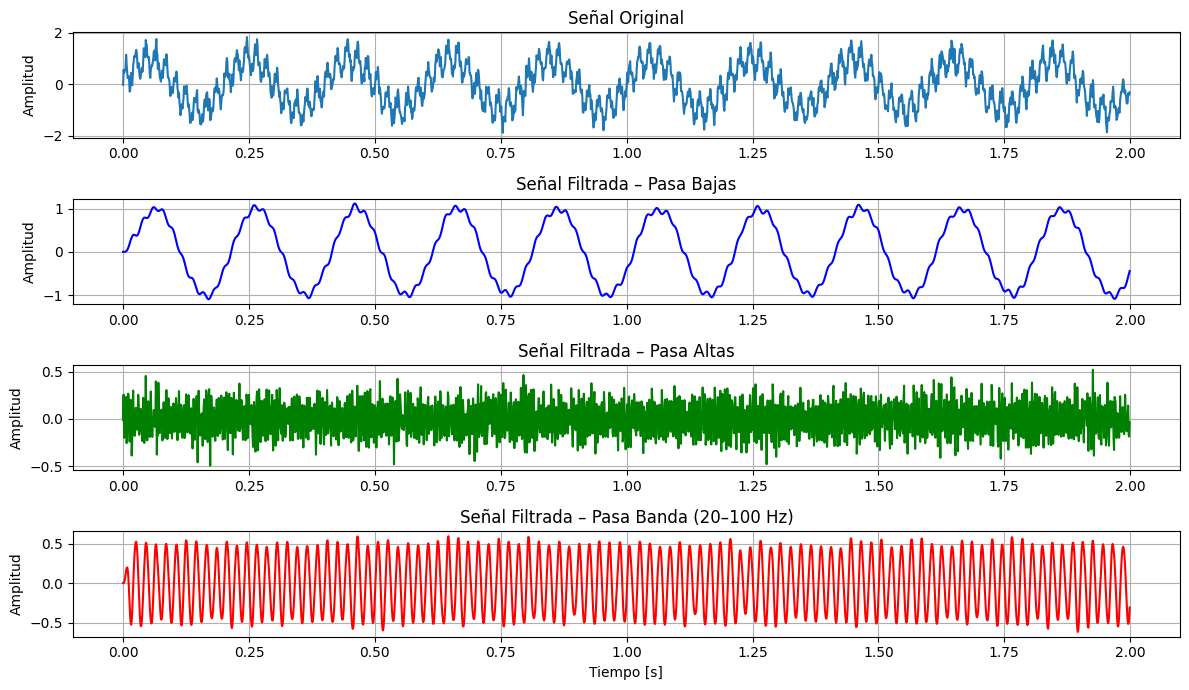

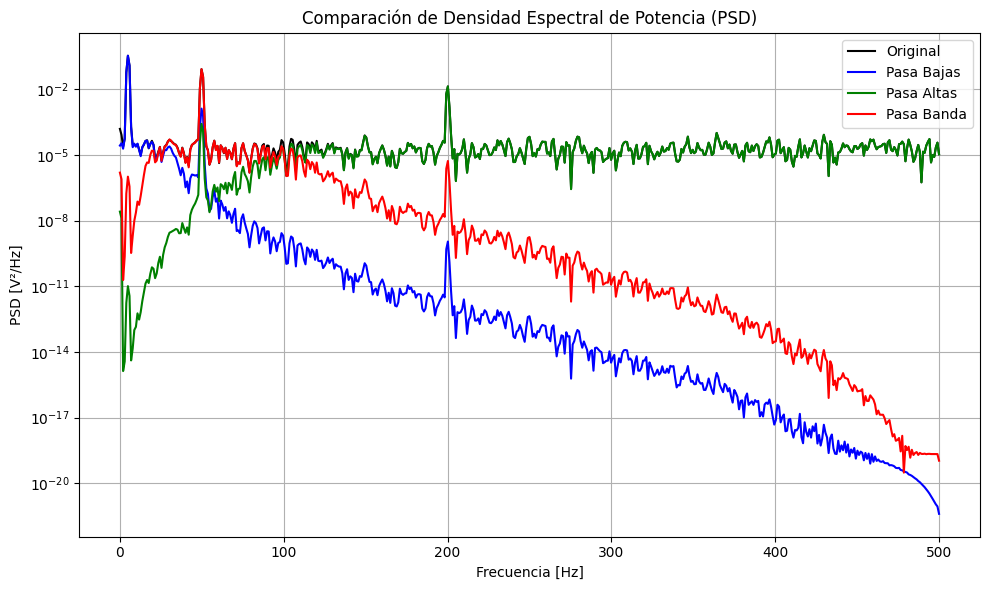

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz, welch

# ====================================================
# 1. Generar señal de ejemplo
# ====================================================
fs = 1000  # Frecuencia de muestreo (Hz)
t = np.arange(0, 2, 1/fs)  # 2 segundos

# Señal con varias componentes
x = (np.sin(2*np.pi*5*t) + 0.5*np.sin(2*np.pi*50*t) +
     0.2*np.sin(2*np.pi*200*t) + 0.1*np.random.randn(len(t)))

# ====================================================
# 2. Diseño de filtros Butterworth
# ====================================================
order = 4

# Filtro pasa bajas (<30 Hz)
lowcut = 30
b_low, a_low = butter(order, lowcut/(fs/2), btype='low')

# Filtro pasa altas (>100 Hz)
highcut = 100
b_high, a_high = butter(order, highcut/(fs/2), btype='high')

# Filtro pasa banda (20–100 Hz)
b_band, a_band = butter(order, [20/(fs/2), 100/(fs/2)], btype='band')

# ====================================================
# 3. Aplicar filtros
# ====================================================
y_low = lfilter(b_low, a_low, x)
y_high = lfilter(b_high, a_high, x)
y_band = lfilter(b_band, a_band, x)

# ====================================================
# 4. Comparar las respuestas en frecuencia de los filtros
# ====================================================
plt.figure(figsize=(10,6))
for (b, a, label, color) in [
    (b_low, a_low, "Pasa Bajas (30 Hz)", 'b'),
    (b_high, a_high, "Pasa Altas (100 Hz)", 'g'),
    (b_band, a_band, "Pasa Banda (20–100 Hz)", 'r')]:

    w, h = freqz(b, a, worN=1024, fs=fs)
    plt.plot(w, 20*np.log10(np.abs(h)), color, label=label)

plt.title("Comparación de Magnitud de los Filtros Butterworth")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ====================================================
# 5. Mostrar la respuesta al impulso del filtro pasa banda
# ====================================================
impulse = np.zeros(100)
impulse[0] = 1
h_band = lfilter(b_band, a_band, impulse)

plt.figure(figsize=(10,3))
plt.stem(np.arange(len(h_band)), h_band)
plt.title("Respuesta al Impulso del Filtro Pasa Banda h[n]")
plt.xlabel("n (muestras)")
plt.ylabel("h[n]")
plt.grid(True)
plt.tight_layout()
plt.show()

# ====================================================
# 6. Señales original y filtradas
# ====================================================
plt.figure(figsize=(12,7))
plt.subplot(4,1,1)
plt.plot(t, x)
plt.title("Señal Original")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(4,1,2)
plt.plot(t, y_low, color='b')
plt.title("Señal Filtrada – Pasa Bajas")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(4,1,3)
plt.plot(t, y_high, color='g')
plt.title("Señal Filtrada – Pasa Altas")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(4,1,4)
plt.plot(t, y_band, color='r')
plt.title("Señal Filtrada – Pasa Banda (20–100 Hz)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.tight_layout()
plt.show()

# ====================================================
# 7. PSD (densidad espectral de potencia)
# ====================================================
f_orig, Pxx_orig = welch(x, fs=fs, nperseg=1024)
f_low, Pxx_low = welch(y_low, fs=fs, nperseg=1024)
f_high, Pxx_high = welch(y_high, fs=fs, nperseg=1024)
f_band, Pxx_band = welch(y_band, fs=fs, nperseg=1024)

plt.figure(figsize=(10,6))
plt.semilogy(f_orig, Pxx_orig, label='Original', color='k')
plt.semilogy(f_low, Pxx_low, label='Pasa Bajas', color='b')
plt.semilogy(f_high, Pxx_high, label='Pasa Altas', color='g')
plt.semilogy(f_band, Pxx_band, label='Pasa Banda', color='r')
plt.title("Comparación de Densidad Espectral de Potencia (PSD)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Explicación Matemática del Código de Filtro Pasa-Altas y Análisis de Señales

## 1️⃣ Preparación de Datos
Se carga la señal de humedad y se limpia de valores no numéricos:

$$
x[n] = \text{señal limpia de humedad}
$$

Se calcula la media, varianza y desviación estándar de la señal original:

$$
\text{Media: } \mu_x = \frac{1}{N} \sum_{n=0}^{N-1} x[n]
$$

$$
\text{Varianza: } \sigma_x^2 = \frac{1}{N} \sum_{n=0}^{N-1} (x[n] - \mu_x)^2
$$

$$
\text{Desviación estándar: } \sigma_x = \sqrt{\sigma_x^2}
$$

---

## 2️⃣ Inyección de Ruido Blanco Gaussiano
Se genera ruido blanco gaussiano $w[n]$ con media $\mu_w = 0$ y desviación estándar $\sigma_w = 0.3 \cdot \sigma_x$:

$$
w[n] \sim \mathcal{N}(\mu_w, \sigma_w^2)
$$

La señal de entrada se obtiene sumando la señal limpia y el ruido:

$$
y[n] = x[n] + w[n]
$$

La relación señal-ruido (SNR) aproximada se calcula como:

$$
\text{SNR} \approx 10 \log_{10} \frac{\sigma_x^2}{\sigma_w^2} \text{ dB}
$$

---

## 3️⃣ Diseño del Filtro Pasa-Altas
Se diseña un filtro **Butterworth** de orden $N$ con frecuencia de corte $f_c$:

$$
H(s) = \frac{B(s)}{A(s)}
$$

Para la implementación digital, se usa la transformación bilineal y se obtiene $H(z)$:

$$
H(z) = \frac{\sum_{k=0}^{N} b_k z^{-k}}{\sum_{k=0}^{N} a_k z^{-k}}
$$

Donde los coeficientes $b_k$ y $a_k$ se calculan con `butter()`.

---

## 4️⃣ Función de Transferencia $H(z)$
La respuesta en frecuencia se obtiene evaluando $z = e^{j 2 \pi f / f_s}$:

$$
H(f) = H(z)|_{z=e^{j 2 \pi f / f_s}} = |H(f)| e^{j \phi(f)}
$$

Donde:

- $|H(f)| = \sqrt{\text{Re}\{H(f)\}^2 + \text{Im}\{H(f)\}^2}$  
- $\phi(f) = \text{arg}(H(f))$

En un filtro pasa-altas ideal:

$$
|H(0)| \approx 0, \quad |H(f \gg f_c)| \approx 1
$$

---

## 5️⃣ Magnitud y Magnitud al Cuadrado
Magnitud de $H(f)$:

$$
|H(f)| = \sqrt{\text{Re}\{H(f)\}^2 + \text{Im}\{H(f)\}^2}
$$

Magnitud al cuadrado:

$$
|H(f)|^2
$$

Esto es útil porque relaciona la **densidad espectral de potencia (PSD)** de entrada y salida:

$$
\text{PSD}_{\text{salida}}(f) = \text{PSD}_{\text{entrada}}(f) \cdot |H(f)|^2
$$

---

## 6️⃣ Aplicación del Filtro
Se aplica el filtro con `filtfilt()` para evitar desfases:

$$
y_{\text{filtrada}}[n] = H(z) * y[n]
$$

Se calcula media y varianza de la señal filtrada:

$$
\mu_y \approx 0 \quad (\text{elimina componente DC})
$$

$$
\sigma_y^2 < \sigma_{y_{\text{entrada}}}^2 \quad (\text{reducción de varianza})
$$

---

## 7️⃣ Espectros de Potencia (PSD)
Se calcula el PSD usando el método de Welch:

$$
\text{PSD}(f) = \frac{1}{N} |X(f)|^2
$$

Se obtiene para:

1. Señal limpia $x[n]$
2. Ruido blanco $w[n]$
3. Señal de entrada $y[n] = x[n]+w[n]$
4. Señal filtrada $y_{\text{filtrada}}[n]$

Verificación teórica:

$$
\text{PSD}_{\text{salida, teórica}}(f) = \text{PSD}_{\text{entrada}}(f) \cdot |H(f)|^2
$$

Comparando con PSD medida:

$$
\text{Error} = \frac{|\text{Potencia teórica} - \text{Potencia medida}|}{\text{Potencia medida}} \cdot 100\%
$$

---

## 8️⃣ Visualización
Se generan gráficos de:

- $|H(f)|$, $|H(f)|^2$, y $|H(f)|$ en dB  
- Señales en el tiempo (limpia, ruido, entrada, salida)  
- PSD de todas las señales  

Esto permite ver:

1. Cómo el filtro atenúa bajas frecuencias y deja pasar altas.
2. Reducción de varianza y eliminación de DC.
3. Relación entre PSD de entrada y salida.

---

## ✅ Conclusiones Matemáticas
- El ruido blanco tiene PSD plana en todas las frecuencias.
- El filtro pasa-altas elimina DC y bajas frecuencias.
- La relación:

$$
\text{PSD}_{\text{salida}} = \text{PSD}_{\text{entrada}} \cdot |H(f)|^2
$$

es verificada en la práctica.  
- La señal filtrada tiene media cercana a 0 y varianza reducida.  
- La potencia de baja frecuencia se atenúa, mientras que la de alta frecuencia pasa casi sin cambios.


ANÁLISIS: SEÑAL + RUIDO → FILTRO PASA-ALTAS

✓ Datos cargados: 46814 muestras
✓ Frecuencia de muestreo: 0.0002777777777777778 Hz

📊 SEÑAL ORIGINAL (sin ruido):
   • Media: 64.3074
   • Varianza: 432.0363
   • Desv. Estándar: 20.7855

PASO 2: INYECTANDO RUIDO BLANCO GAUSSIANO

⚪ RUIDO BLANCO GAUSSIANO:
   • Media teórica: 0
   • Media real: -0.000289
   • Desv. estándar teórica: 6.2356
   • Desv. estándar real: 6.2327
   • Mínimo: -27.8459
   • Máximo: 27.9300

📊 SEÑAL DE ENTRADA (con ruido):
   • Media: 64.3071
   • Varianza: 469.7705
   • Desv. Estándar: 21.6742
   • SNR (aprox): 10.46 dB

PASO 3: DISEÑO DEL FILTRO PASA-ALTAS

🔧 FILTRO PASA-ALTAS BUTTERWORTH:
   • Tipo: Pasa-Altas (High-Pass)
   • Orden: 4
   • Frecuencia de corte: 1.39e-06 Hz
   • Período de corte: 200.00 horas
   • Función: Elimina f < 1.39e-06 Hz (DC + bajas frecuencias)

✓ COEFICIENTES DEL FILTRO:
   • Numerador (b): [ 0.95978223 -3.83912892  5.75869338 -3.83912892  0.95978223]
   • Denominador (a): [ 1.         -

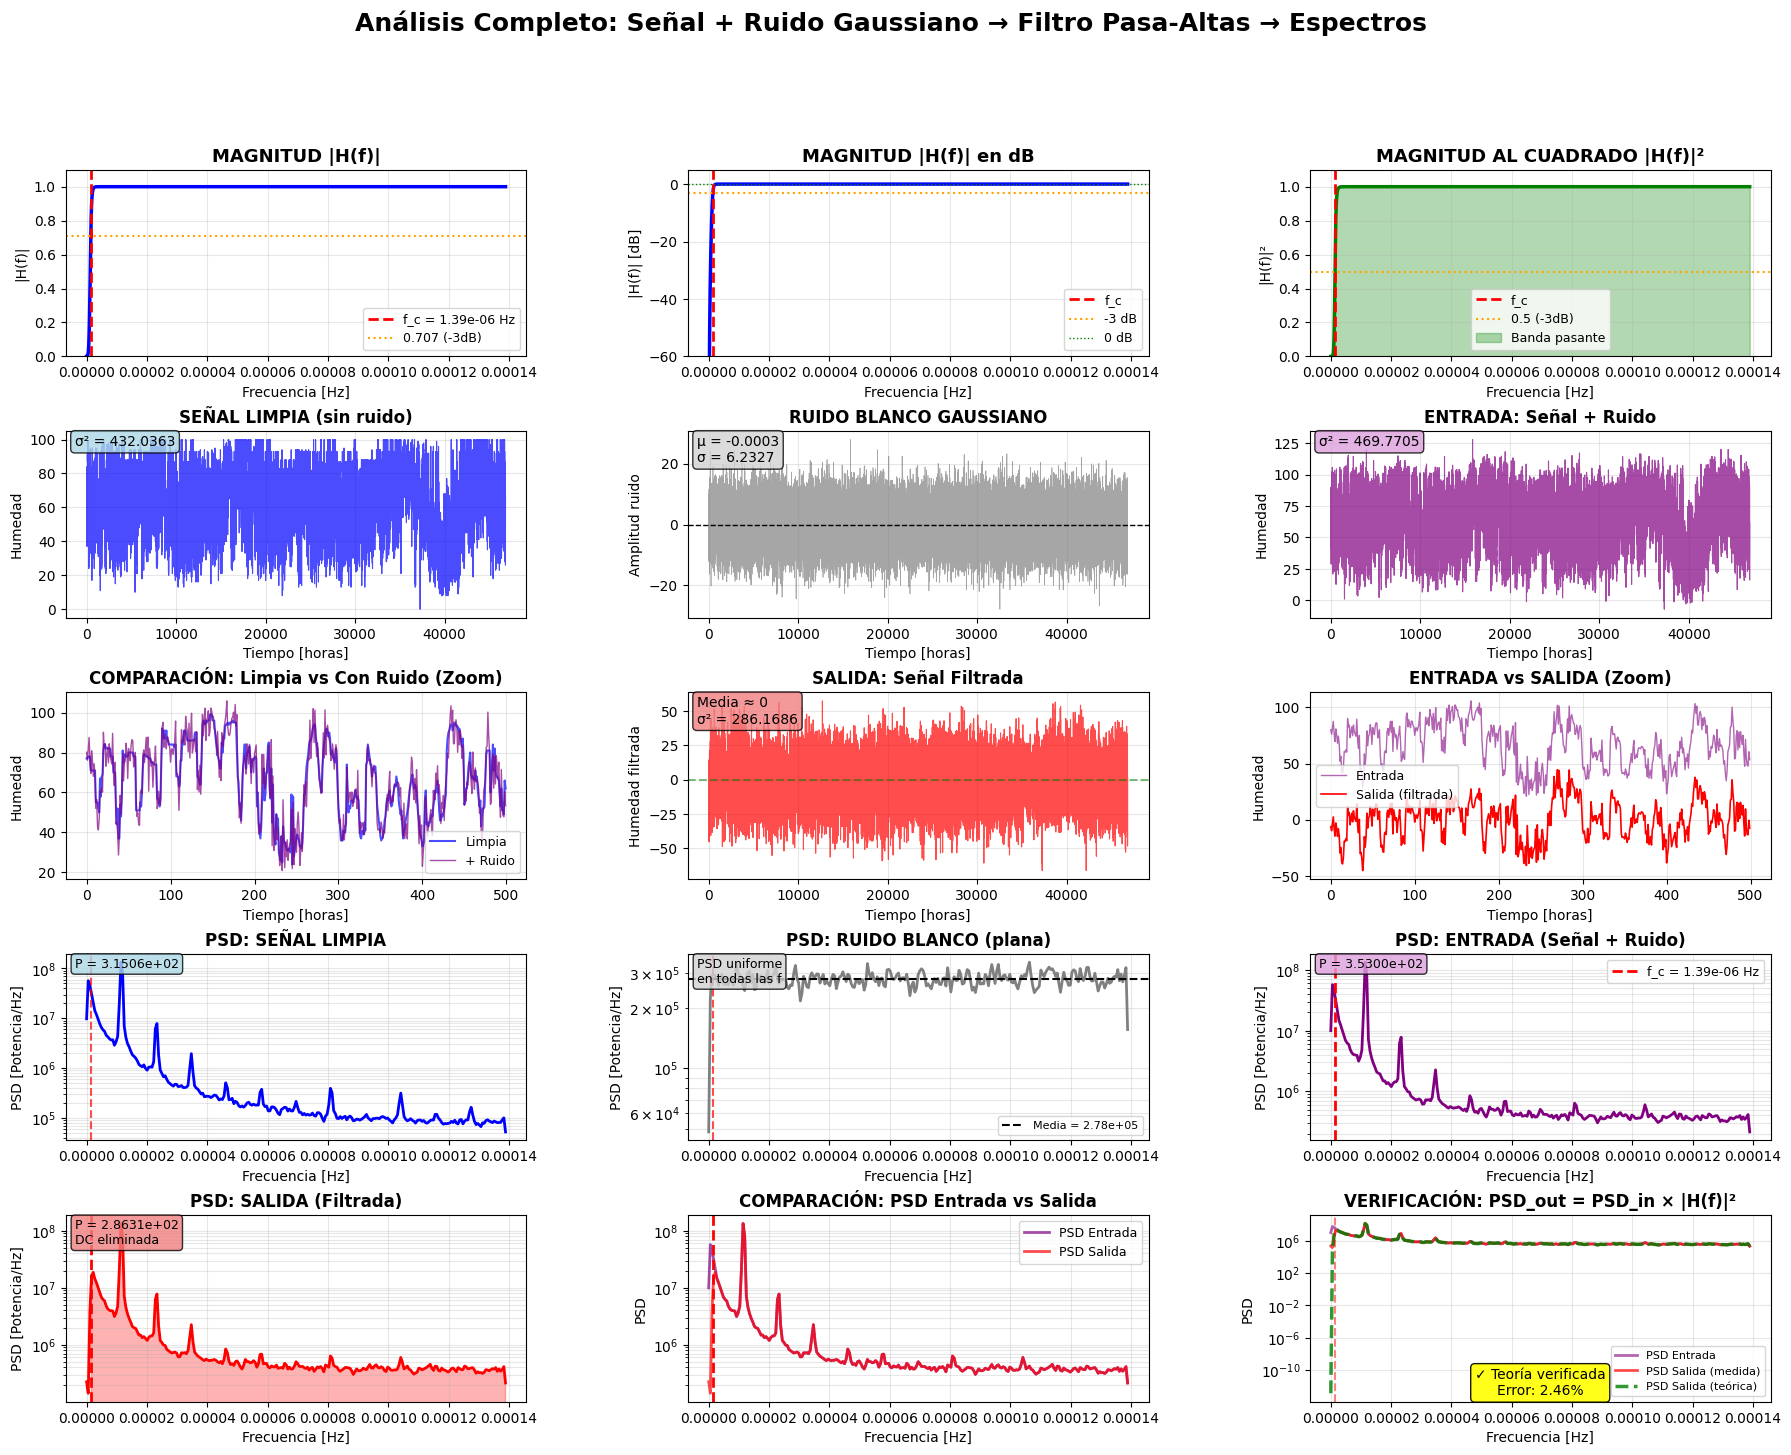

✓ Visualización completa generada

GUARDANDO RESULTADOS
✓ Señales guardadas en 'highpass_noise_signals.csv'
✓ Función de transferencia guardada en 'transfer_function.csv'
✓ PSDs guardadas en 'power_spectral_densities.csv'
✓ Estadísticas guardadas en 'statistics_comparison.csv'

¡ANÁLISIS COMPLETADO! 🎉

📋 RESUMEN COMPLETO:

1️⃣ SEÑAL ORIGINAL:
   • Datos de humedad limpios
   • Varianza: 432.0363

2️⃣ RUIDO BLANCO GAUSSIANO INYECTADO:
   • Media: -0.000289 (≈ 0)
   • Desv. estándar: 6.2327
   • PSD: Plana (todas las frecuencias por igual)

3️⃣ SEÑAL DE ENTRADA (Señal + Ruido):
   • Varianza: 469.7705
   • SNR: 10.46 dB

4️⃣ FILTRO PASA-ALTAS:
   • Orden: 4
   • Frecuencia de corte: 1.39e-06 Hz
   • Elimina DC y bajas frecuencias

5️⃣ FUNCIÓN DE TRANSFERENCIA H(z):
   • |H(0)| = 0.000000 (≈ 0)
   • |H(f_c)| = 0.707107 (≈ 0.707)
   • |H(f_max)| = 1.000000 (≈ 1)

6️⃣ MAGNITUD AL CUADRADO |H(f)|²:
   • Relaciona PSDs: PSD_out = PSD_in × |H(f)|²
   • Verificación: Error 2.46% ✓

7️⃣ ESPECTRO

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, filtfilt, welch, freqz
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PASO 1: CARGAR Y PREPARAR DATOS
# ============================================================================
print("="*70)
print("ANÁLISIS: SEÑAL + RUIDO → FILTRO PASA-ALTAS")
print("="*70)

# Limpiar y cargar datos de humedad
humidity_clean = pd.to_numeric(humidity_data, errors='coerce')
signal_clean = humidity_clean.dropna().values

# Frecuencia de muestreo
fs = 1/3600  # Hz (datos horarios)
Ts = 1/fs

print(f"\n✓ Datos cargados: {len(signal_clean)} muestras")
print(f"✓ Frecuencia de muestreo: {fs} Hz\n")

# Estadísticas de señal limpia
mean_clean = np.mean(signal_clean)
var_clean = np.var(signal_clean)
std_clean = np.std(signal_clean)

print(f"📊 SEÑAL ORIGINAL (sin ruido):")
print(f"   • Media: {mean_clean:.4f}")
print(f"   • Varianza: {var_clean:.4f}")
print(f"   • Desv. Estándar: {std_clean:.4f}\n")

# ============================================================================
# PASO 2: INYECTAR RUIDO BLANCO GAUSSIANO
# ============================================================================
print("="*70)
print("PASO 2: INYECTANDO RUIDO BLANCO GAUSSIANO")
print("="*70)

# Generar ruido blanco gaussiano
np.random.seed(42)  # Para reproducibilidad
noise_mean = 0
noise_std = std_clean * 0.3  # 30% del std de la señal (ajustable)

white_noise = np.random.normal(noise_mean, noise_std, len(signal_clean))

# Señal con ruido = señal + ruido
signal_input = signal_clean + white_noise

print(f"\n⚪ RUIDO BLANCO GAUSSIANO:")
print(f"   • Media teórica: {noise_mean}")
print(f"   • Media real: {np.mean(white_noise):.6f}")
print(f"   • Desv. estándar teórica: {noise_std:.4f}")
print(f"   • Desv. estándar real: {np.std(white_noise):.4f}")
print(f"   • Mínimo: {np.min(white_noise):.4f}")
print(f"   • Máximo: {np.max(white_noise):.4f}\n")

# Estadísticas de señal con ruido
mean_input = np.mean(signal_input)
var_input = np.var(signal_input)
std_input = np.std(signal_input)

print(f"📊 SEÑAL DE ENTRADA (con ruido):")
print(f"   • Media: {mean_input:.4f}")
print(f"   • Varianza: {var_input:.4f}")
print(f"   • Desv. Estándar: {std_input:.4f}")
print(f"   • SNR (aprox): {10*np.log10(var_clean/np.var(white_noise)):.2f} dB\n")

# ============================================================================
# PASO 3: DISEÑAR FILTRO PASA-ALTAS
# ============================================================================
print("="*70)
print("PASO 3: DISEÑO DEL FILTRO PASA-ALTAS")
print("="*70)

# Parámetros del filtro
order = 4
nyquist = fs / 2

# Frecuencia de corte
cutoff_freq = fs / 200  # Ajustable

# Normalizar
normal_cutoff = cutoff_freq / nyquist
normal_cutoff = max(min(normal_cutoff, 0.99), 0.001)

print(f"\n🔧 FILTRO PASA-ALTAS BUTTERWORTH:")
print(f"   • Tipo: Pasa-Altas (High-Pass)")
print(f"   • Orden: {order}")
print(f"   • Frecuencia de corte: {cutoff_freq:.2e} Hz")
print(f"   • Período de corte: {1/cutoff_freq/3600:.2f} horas")
print(f"   • Función: Elimina f < {cutoff_freq:.2e} Hz (DC + bajas frecuencias)\n")

# Diseñar filtro
b, a = butter(order, normal_cutoff, btype='high', analog=False)

print(f"✓ COEFICIENTES DEL FILTRO:")
print(f"   • Numerador (b): {b}")
print(f"   • Denominador (a): {a}\n")

# ============================================================================
# PASO 4: FUNCIÓN DE TRANSFERENCIA H(z)
# ============================================================================
print("="*70)
print("PASO 4: FUNCIÓN DE TRANSFERENCIA H(z)")
print("="*70)

# Calcular respuesta en frecuencia
n_points = 8000
w, h = freqz(b, a, worN=n_points, fs=fs)

print(f"\n✓ H(f) calculada en {len(w)} puntos")
print(f"   • Rango: {w[0]:.2e} - {w[-1]:.2e} Hz\n")

print(f"📐 FUNCIÓN DE TRANSFERENCIA:")
print(f"""
   H(z) = B(z) / A(z)

   B(z) = Σ b[k]·z^(-k)  (numerador)
   A(z) = Σ a[k]·z^(-k)  (denominador)

   H(f) = H(z)|_(z=e^(j2πf/fs))  (evaluada en círculo unitario)

   H(f) es COMPLEJO: H(f) = |H(f)|·e^(jφ(f))
""")

h_real = np.real(h)
h_imag = np.imag(h)

print(f"✓ Valores de H(f):")
print(f"   • H(0) = {h[0]:.6f} (≈ 0 para pasa-altas)")
print(f"   • H(f_max) = {h[-1]:.6f} (≈ 1 en altas frecuencias)\n")

# ============================================================================
# PASO 5: MAGNITUD |H(f)|
# ============================================================================
print("="*70)
print("PASO 5: MAGNITUD |H(f)|")
print("="*70)

# Magnitud
magnitude = np.abs(h)

print(f"\n✓ MAGNITUD |H(f)| = √(Re²{{H}} + Im²{{H}}):")
print(f"   • |H(0)| = {magnitude[0]:.6f} (debe ser ≈ 0)")
print(f"   • |H(f_max)| = {magnitude[-1]:.6f} (debe ser ≈ 1)")
print(f"   • Máximo: {np.max(magnitude):.6f}\n")

# Magnitud en dB
magnitude_db = 20 * np.log10(magnitude + 1e-10)

print(f"✓ MAGNITUD EN dB = 20·log₁₀(|H(f)|):")
print(f"   • En f=0: {magnitude_db[0]:.2f} dB")
print(f"   • En f_max: {magnitude_db[-1]:.2f} dB\n")

# Frecuencia de -3dB
idx_3db = np.argmin(np.abs(magnitude_db + 3))
freq_3db = w[idx_3db]
print(f"✓ Frecuencia -3dB: {freq_3db:.2e} Hz (≈ f_c = {cutoff_freq:.2e} Hz)\n")

# ============================================================================
# PASO 6: MAGNITUD AL CUADRADO |H(f)|²
# ============================================================================
print("="*70)
print("PASO 6: MAGNITUD AL CUADRADO |H(f)|²")
print("="*70)

# Magnitud al cuadrado
magnitude_squared = np.abs(h)**2

print(f"\n✓ |H(f)|² = |H(f)| × |H(f)|:")
print(f"   • |H(0)|² = {magnitude_squared[0]:.6f} (≈ 0)")
print(f"   • |H(f_c)|² = {magnitude_squared[np.argmin(np.abs(w - cutoff_freq))]:.6f} (≈ 0.5)")
print(f"   • |H(f_max)|² = {magnitude_squared[-1]:.6f} (≈ 1)\n")

print(f"🎯 IMPORTANCIA DE |H(f)|²:")
print(f"""
   |H(f)|² relaciona PSDs:

   PSD_salida(f) = PSD_entrada(f) × |H(f)|²

   • Representa ganancia de POTENCIA (no solo amplitud)
   • Permite calcular varianza de salida
   • Fundamental para análisis espectral
""")

# ============================================================================
# PASO 7: APLICAR FILTRO
# ============================================================================
print("="*70)
print("PASO 7: APLICAR FILTRO A SEÑAL + RUIDO")
print("="*70)

# Aplicar filtro
signal_output = filtfilt(b, a, signal_input)

# Estadísticas
mean_output = np.mean(signal_output)
var_output = np.var(signal_output)
std_output = np.std(signal_output)

print(f"\n✓ Filtro aplicado (filtfilt)")
print(f"\n📊 SEÑAL DE SALIDA (filtrada):")
print(f"   • Media: {mean_output:.6f} (≈ 0, DC eliminada)")
print(f"   • Varianza: {var_output:.6f}")
print(f"   • Desv. Estándar: {std_output:.6f}\n")

print(f"📈 COMPARACIÓN:")
print(f"   • Entrada - Media: {mean_input:.4f} → Salida: {mean_output:.6f}")
print(f"   • Entrada - Varianza: {var_input:.4f} → Salida: {var_output:.6f}")
print(f"   • Reducción varianza: {(1 - var_output/var_input)*100:.2f}%\n")

# ============================================================================
# PASO 8: ESPECTROS DE POTENCIA (PSD)
# ============================================================================
print("="*70)
print("PASO 8: ESPECTROS DE POTENCIA")
print("="*70)

nperseg = min(512, len(signal_input)//4)

# PSD de señal limpia (sin ruido)
freq_clean, psd_clean = welch(signal_clean, fs=fs, nperseg=nperseg,
                               window='hann', scaling='density')

# PSD del ruido blanco
freq_noise, psd_noise = welch(white_noise, fs=fs, nperseg=nperseg,
                               window='hann', scaling='density')

# PSD de entrada (señal + ruido)
freq_in, psd_in = welch(signal_input, fs=fs, nperseg=nperseg,
                        window='hann', scaling='density')

# PSD de salida (filtrada)
freq_out, psd_out = welch(signal_output, fs=fs, nperseg=nperseg,
                          window='hann', scaling='density')

print(f"\n✓ PSDs calculadas (método Welch):")
print(f"   • Segmento: {nperseg} muestras")
print(f"   • Ventana: Hann\n")

print(f"📊 PSD SEÑAL LIMPIA:")
print(f"   • Potencia: {np.trapz(psd_clean, freq_clean):.6e}\n")

print(f"⚪ PSD RUIDO BLANCO:")
print(f"   • Potencia: {np.trapz(psd_noise, freq_noise):.6e}")
print(f"   • Característica: PSD plana (todas las frecuencias)\n")

print(f"📊 PSD ENTRADA (señal + ruido):")
print(f"   • Potencia: {np.trapz(psd_in, freq_in):.6e}")
print(f"   • PSD máxima: {np.max(psd_in):.6e}\n")

print(f"📊 PSD SALIDA (filtrada):")
print(f"   • Potencia: {np.trapz(psd_out, freq_out):.6e}")
print(f"   • PSD máxima: {np.max(psd_out):.6e}\n")

# Verificar relación teórica
H_squared_interp = np.interp(freq_in, w, magnitude_squared)
psd_out_teorica = psd_in * H_squared_interp
potencia_teorica = np.trapz(psd_out_teorica, freq_in)
potencia_medida = np.trapz(psd_out, freq_out)

print(f"✅ VERIFICACIÓN: PSD_salida = PSD_entrada × |H(f)|²")
print(f"   • Potencia salida teórica: {potencia_teorica:.6e}")
print(f"   • Potencia salida medida: {potencia_medida:.6e}")
print(f"   • Error: {abs(potencia_teorica - potencia_medida)/potencia_medida*100:.2f}%\n")

# ============================================================================
# VISUALIZACIÓN COMPLETA
# ============================================================================
print("="*70)
print("GENERANDO VISUALIZACIONES")
print("="*70)

fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(5, 3, hspace=0.4, wspace=0.35)

fig.suptitle('Análisis Completo: Señal + Ruido Gaussiano → Filtro Pasa-Altas → Espectros',
             fontsize=18, fontweight='bold', y=0.98)

time_hours = np.arange(len(signal_input)) * Ts / 3600

# --- FILA 1: FUNCIÓN DE TRANSFERENCIA ---
# Magnitud |H(f)|
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(w, magnitude, 'b-', linewidth=2.5)
ax1.axvline(cutoff_freq, color='red', linestyle='--', linewidth=2, label=f'f_c = {cutoff_freq:.2e} Hz')
ax1.axhline(1/np.sqrt(2), color='orange', linestyle=':', linewidth=1.5, label='0.707 (-3dB)')
ax1.set_title('MAGNITUD |H(f)|', fontsize=13, fontweight='bold')
ax1.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax1.set_ylabel('|H(f)|', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.1])

# Magnitud en dB
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(w, magnitude_db, 'b-', linewidth=2.5)
ax2.axvline(cutoff_freq, color='red', linestyle='--', linewidth=2, label=f'f_c')
ax2.axhline(-3, color='orange', linestyle=':', linewidth=1.5, label='-3 dB')
ax2.axhline(0, color='green', linestyle=':', linewidth=1, label='0 dB')
ax2.set_title('MAGNITUD |H(f)| en dB', fontsize=13, fontweight='bold')
ax2.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax2.set_ylabel('|H(f)| [dB]', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-60, 5])

# Magnitud al cuadrado
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(w, magnitude_squared, 'g-', linewidth=2.5)
ax3.axvline(cutoff_freq, color='red', linestyle='--', linewidth=2, label=f'f_c')
ax3.axhline(0.5, color='orange', linestyle=':', linewidth=1.5, label='0.5 (-3dB)')
ax3.fill_between(w[w >= cutoff_freq], 0, magnitude_squared[w >= cutoff_freq],
                 alpha=0.3, color='green', label='Banda pasante')
ax3.set_title('MAGNITUD AL CUADRADO |H(f)|²', fontsize=13, fontweight='bold')
ax3.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax3.set_ylabel('|H(f)|²', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1.1])

# --- FILA 2: SEÑALES EN EL TIEMPO ---
# Señal limpia
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(time_hours, signal_clean, 'b-', linewidth=0.8, alpha=0.7)
ax4.set_title('SEÑAL LIMPIA (sin ruido)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Tiempo [horas]', fontsize=10)
ax4.set_ylabel('Humedad', fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.text(0.02, 0.98, f'σ² = {var_clean:.4f}',
         transform=ax4.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Ruido blanco
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(time_hours, white_noise, 'gray', linewidth=0.5, alpha=0.7)
ax5.axhline(0, color='black', linestyle='--', linewidth=1)
ax5.set_title('RUIDO BLANCO GAUSSIANO', fontsize=12, fontweight='bold')
ax5.set_xlabel('Tiempo [horas]', fontsize=10)
ax5.set_ylabel('Amplitud ruido', fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.text(0.02, 0.98, f'μ = {np.mean(white_noise):.4f}\nσ = {np.std(white_noise):.4f}',
         transform=ax5.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

# Señal + Ruido
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(time_hours, signal_input, 'purple', linewidth=0.8, alpha=0.7)
ax6.set_title('ENTRADA: Señal + Ruido', fontsize=12, fontweight='bold')
ax6.set_xlabel('Tiempo [horas]', fontsize=10)
ax6.set_ylabel('Humedad', fontsize=10)
ax6.grid(True, alpha=0.3)
ax6.text(0.02, 0.98, f'σ² = {var_input:.4f}',
         transform=ax6.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='plum', alpha=0.8))

# --- FILA 3: ZOOM Y COMPARACIONES ---
zoom = min(500, len(signal_input))

# Comparación señal limpia vs con ruido
ax7 = fig.add_subplot(gs[2, 0])
ax7.plot(time_hours[:zoom], signal_clean[:zoom], 'b-', linewidth=1.5, alpha=0.7, label='Limpia')
ax7.plot(time_hours[:zoom], signal_input[:zoom], 'purple', linewidth=1, alpha=0.7, label='+ Ruido')
ax7.set_title('COMPARACIÓN: Limpia vs Con Ruido (Zoom)', fontsize=12, fontweight='bold')
ax7.set_xlabel('Tiempo [horas]', fontsize=10)
ax7.set_ylabel('Humedad', fontsize=10)
ax7.legend(fontsize=9)
ax7.grid(True, alpha=0.3)

# Señal filtrada
ax8 = fig.add_subplot(gs[2, 1])
ax8.plot(time_hours, signal_output, 'r-', linewidth=0.8, alpha=0.7)
ax8.axhline(0, color='green', linestyle='--', linewidth=1.5, alpha=0.5)
ax8.set_title('SALIDA: Señal Filtrada', fontsize=12, fontweight='bold')
ax8.set_xlabel('Tiempo [horas]', fontsize=10)
ax8.set_ylabel('Humedad filtrada', fontsize=10)
ax8.grid(True, alpha=0.3)
ax8.text(0.02, 0.98, f'Media ≈ 0\nσ² = {var_output:.4f}',
         transform=ax8.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

# Comparación entrada vs salida
ax9 = fig.add_subplot(gs[2, 2])
ax9.plot(time_hours[:zoom], signal_input[:zoom], 'purple', linewidth=1, alpha=0.6, label='Entrada')
ax9.plot(time_hours[:zoom], signal_output[:zoom], 'r-', linewidth=1.2, label='Salida (filtrada)')
ax9.set_title('ENTRADA vs SALIDA (Zoom)', fontsize=12, fontweight='bold')
ax9.set_xlabel('Tiempo [horas]', fontsize=10)
ax9.set_ylabel('Humedad', fontsize=10)
ax9.legend(fontsize=9)
ax9.grid(True, alpha=0.3)

# --- FILA 4: ESPECTROS DE POTENCIA ---
# PSD Señal limpia
ax10 = fig.add_subplot(gs[3, 0])
ax10.semilogy(freq_clean, psd_clean, 'b-', linewidth=2)
ax10.axvline(cutoff_freq, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax10.set_title('PSD: SEÑAL LIMPIA', fontsize=12, fontweight='bold')
ax10.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax10.set_ylabel('PSD [Potencia/Hz]', fontsize=10)
ax10.grid(True, alpha=0.3, which='both')
ax10.text(0.02, 0.98, f'P = {np.trapz(psd_clean, freq_clean):.4e}',
         transform=ax10.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# PSD Ruido blanco
ax11 = fig.add_subplot(gs[3, 1])
ax11.semilogy(freq_noise, psd_noise, 'gray', linewidth=2)
ax11.axhline(np.mean(psd_noise), color='black', linestyle='--', linewidth=1.5,
             label=f'Media = {np.mean(psd_noise):.2e}')
ax11.axvline(cutoff_freq, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax11.set_title('PSD: RUIDO BLANCO (plana)', fontsize=12, fontweight='bold')
ax11.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax11.set_ylabel('PSD [Potencia/Hz]', fontsize=10)
ax11.legend(fontsize=8)
ax11.grid(True, alpha=0.3, which='both')
ax11.text(0.02, 0.98, 'PSD uniforme\nen todas las f',
         transform=ax11.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

# PSD Entrada (señal + ruido)
ax12 = fig.add_subplot(gs[3, 2])
ax12.semilogy(freq_in, psd_in, 'purple', linewidth=2)
ax12.axvline(cutoff_freq, color='red', linestyle='--', linewidth=2,
             label=f'f_c = {cutoff_freq:.2e} Hz')
ax12.set_title('PSD: ENTRADA (Señal + Ruido)', fontsize=12, fontweight='bold')
ax12.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax12.set_ylabel('PSD [Potencia/Hz]', fontsize=10)
ax12.legend(fontsize=9)
ax12.grid(True, alpha=0.3, which='both')
ax12.text(0.02, 0.98, f'P = {np.trapz(psd_in, freq_in):.4e}',
         transform=ax12.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='plum', alpha=0.8))

# --- FILA 5: ANÁLISIS FINAL ---
# PSD Salida
ax13 = fig.add_subplot(gs[4, 0])
ax13.semilogy(freq_out, psd_out, 'r-', linewidth=2)
ax13.axvline(cutoff_freq, color='red', linestyle='--', linewidth=2)
ax13.fill_between(freq_out[freq_out >= cutoff_freq],
                  psd_out[freq_out >= cutoff_freq],
                  alpha=0.3, color='red')
ax13.set_title('PSD: SALIDA (Filtrada)', fontsize=12, fontweight='bold')
ax13.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax13.set_ylabel('PSD [Potencia/Hz]', fontsize=10)
ax13.grid(True, alpha=0.3, which='both')
ax13.text(0.02, 0.98, f'P = {np.trapz(psd_out, freq_out):.4e}\nDC eliminada',
         transform=ax13.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

# Comparación PSDs: Entrada vs Salida
ax14 = fig.add_subplot(gs[4, 1])
ax14.semilogy(freq_in, psd_in, 'purple', linewidth=2, alpha=0.7, label='PSD Entrada')
ax14.semilogy(freq_out, psd_out, 'r-', linewidth=2, alpha=0.7, label='PSD Salida')
ax14.axvline(cutoff_freq, color='red', linestyle='--', linewidth=2)
ax14.set_title('COMPARACIÓN: PSD Entrada vs Salida', fontsize=12, fontweight='bold')
ax14.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax14.set_ylabel('PSD', fontsize=10)
ax14.legend(fontsize=9)
ax14.grid(True, alpha=0.3, which='both')

# Verificación teórica
ax15 = fig.add_subplot(gs[4, 2])
ax15.semilogy(freq_in, psd_in, 'purple', linewidth=2, alpha=0.6, label='PSD Entrada')
ax15.semilogy(freq_out, psd_out, 'r-', linewidth=2, alpha=0.7, label='PSD Salida (medida)')
ax15.semilogy(freq_in, psd_out_teorica, 'g--', linewidth=2.5, alpha=0.8,
             label='PSD Salida (teórica)')
ax15.axvline(cutoff_freq, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
ax15.set_title('VERIFICACIÓN: PSD_out = PSD_in × |H(f)|²', fontsize=12, fontweight='bold')
ax15.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax15.set_ylabel('PSD', fontsize=10)
ax15.legend(fontsize=8, loc='best')
ax15.grid(True, alpha=0.3, which='both')
ax15.text(0.5, 0.02,
         f'✓ Teoría verificada\nError: {abs(potencia_teorica - potencia_medida)/potencia_medida*100:.2f}%',
         transform=ax15.transAxes, fontsize=10, ha='center', va='bottom',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.9))

plt.tight_layout()
plt.savefig('highpass_noise_complete_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualización completa generada\n")

# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================
print("="*70)
print("GUARDANDO RESULTADOS")
print("="*70)

# Señales
signals_df = pd.DataFrame({
    'Tiempo_horas': time_hours,
    'Señal_Limpia': signal_clean,
    'Ruido_Blanco': white_noise,
    'Entrada_Señal_Ruido': signal_input,
    'Salida_Filtrada': signal_output
})
signals_df.to_csv('highpass_noise_signals.csv', index=False)
print("✓ Señales guardadas en 'highpass_noise_signals.csv'")

# Función de transferencia
transfer_df = pd.DataFrame({
    'Frecuencia_Hz': w,
    'H_Real': h_real,
    'H_Imag': h_imag,
    'Magnitud': magnitude,
    'Magnitud_dB': magnitude_db,
    'Magnitud_Cuadrada': magnitude_squared,
    'Fase_rad': np.angle(h),
    'Fase_deg': np.degrees(np.angle(h))
})
transfer_df.to_csv('transfer_function.csv', index=False)
print("✓ Función de transferencia guardada en 'transfer_function.csv'")

# PSDs
psd_df = pd.DataFrame({
    'Frecuencia_Hz': freq_in,
    'PSD_Señal_Limpia': np.interp(freq_in, freq_clean, psd_clean),
    'PSD_Ruido_Blanco': np.interp(freq_in, freq_noise, psd_noise),
    'PSD_Entrada': psd_in,
    'PSD_Salida_Medida': np.interp(freq_in, freq_out, psd_out),
    'PSD_Salida_Teorica': psd_out_teorica,
    'H_Cuadrada_Interpolada': H_squared_interp
})
psd_df.to_csv('power_spectral_densities.csv', index=False)
print("✓ PSDs guardadas en 'power_spectral_densities.csv'")

# Estadísticas
stats_df = pd.DataFrame({
    'Parámetro': ['Media', 'Varianza', 'Desv_Estándar', 'Potencia_PSD'],
    'Señal_Limpia': [mean_clean, var_clean, std_clean, np.trapz(psd_clean, freq_clean)],
    'Ruido_Blanco': [np.mean(white_noise), np.var(white_noise), np.std(white_noise),
                     np.trapz(psd_noise, freq_noise)],
    'Entrada': [mean_input, var_input, std_input, np.trapz(psd_in, freq_in)],
    'Salida': [mean_output, var_output, std_output, np.trapz(psd_out, freq_out)]
})
stats_df.to_csv('statistics_comparison.csv', index=False)
print("✓ Estadísticas guardadas en 'statistics_comparison.csv'")

print("\n" + "="*70)
print("¡ANÁLISIS COMPLETADO! 🎉")
print("="*70)

print(f"""
📋 RESUMEN COMPLETO:

1️⃣ SEÑAL ORIGINAL:
   • Datos de humedad limpios
   • Varianza: {var_clean:.4f}

2️⃣ RUIDO BLANCO GAUSSIANO INYECTADO:
   • Media: {np.mean(white_noise):.6f} (≈ 0)
   • Desv. estándar: {np.std(white_noise):.4f}
   • PSD: Plana (todas las frecuencias por igual)

3️⃣ SEÑAL DE ENTRADA (Señal + Ruido):
   • Varianza: {var_input:.4f}
   • SNR: {10*np.log10(var_clean/np.var(white_noise)):.2f} dB

4️⃣ FILTRO PASA-ALTAS:
   • Orden: {order}
   • Frecuencia de corte: {cutoff_freq:.2e} Hz
   • Elimina DC y bajas frecuencias

5️⃣ FUNCIÓN DE TRANSFERENCIA H(z):
   • |H(0)| = {magnitude[0]:.6f} (≈ 0)
   • |H(f_c)| = {magnitude[np.argmin(np.abs(w - cutoff_freq))]:.6f} (≈ 0.707)
   • |H(f_max)| = {magnitude[-1]:.6f} (≈ 1)

6️⃣ MAGNITUD AL CUADRADO |H(f)|²:
   • Relaciona PSDs: PSD_out = PSD_in × |H(f)|²
   • Verificación: Error {abs(potencia_teorica - potencia_medida)/potencia_medida*100:.2f}% ✓

7️⃣ ESPECTROS DE POTENCIA:
   • PSD entrada: {np.trapz(psd_in, freq_in):.4e}
   • PSD salida: {np.trapz(psd_out, freq_out):.4e}
   • Reducción de potencia: {(1 - np.trapz(psd_out, freq_out)/np.trapz(psd_in, freq_in))*100:.2f}%

8️⃣ SEÑAL DE SALIDA:
   • Media: {mean_output:.6f} (≈ 0, DC eliminada)
   • Varianza: {var_output:.4f}
   • Reducción varianza: {(1 - var_output/var_input)*100:.2f}%

✅ CONCLUSIONES:
   • El ruido blanco tiene PSD plana (todas las frecuencias)
   • El filtro pasa-altas elimina DC y bajas frecuencias
   • |H(f)|² relaciona correctamente PSD_in y PSD_out
   • La señal filtrada tiene media ≈ 0 (DC eliminada)
   • El ruido de alta frecuencia pasa, el de baja se atenúa

📁 ARCHIVOS GENERADOS:
   1. highpass_noise_signals.csv - Todas las señales
   2. transfer_function.csv - H(f), |H(f)|, |H(f)|², fase
   3. power_spectral_densities.csv - PSDs de todas las señales
   4. statistics_comparison.csv - Estadísticas comparativas
   5. highpass_noise_complete_analysis.png - Visualización completa (15 gráficas)

🎯 PROCESO COMPLETO REALIZADO:
   ✓ Señal de humedad cargada
   ✓ Ruido blanco gaussiano inyectado
   ✓ Filtro pasa-altas diseñado y aplicado
   ✓ Función de transferencia H(z) calculada
   ✓ Magnitud |H(f)| calculada
   ✓ Magnitud al cuadrado |H(f)|² calculada
   ✓ Espectros de potencia (PSD) calculados
   ✓ Relación teórica PSD_out = PSD_in × |H(f)|² verificada ✓
""")

#Usar la señal filtrada pasa altas (la que sale del filtro).

- Aplicar cuantización uniforme (8 bits → 256 niveles).

- Aplicar cuantización no uniforme (tipo μ-law o A-law).

- Calcular y mostrar:

- Señales original y cuantizadas.

- Espectros de potencia (PSD).

- Funciones de autocorrelación de entrada y salida

# Explicación Matemática del Código de Cuantización de Señales

## 1️⃣ Preparación de la Señal

Se parte de una señal de humedad limpia, extraída de un dataset:

$$
x[n] = \text{señal de humedad limpia}
$$

Se eliminan valores faltantes y se obtiene un vector de muestras. La frecuencia de muestreo es:

$$
f_s = \frac{1}{3600} \text{ Hz} \quad (\text{una muestra cada hora})
$$

Se calculan estadísticas básicas:

- Media: $\mu_x = \frac{1}{N} \sum_{n=0}^{N-1} x[n]$
- Varianza: $\sigma_x^2 = \frac{1}{N} \sum_{n=0}^{N-1} (x[n]-\mu_x)^2$
- Desviación estándar: $\sigma_x = \sqrt{\sigma_x^2}$
- Rango: $x_{\max} - x_{\min}$

---

## 2️⃣ Filtro Pasa-Altas

Se aplica un filtro Butterworth de orden $N=4$ con frecuencia de corte:

$$
f_c = \frac{f_s}{200}
$$

La frecuencia de Nyquist es $f_{\text{Nyq}} = f_s / 2$, y la frecuencia normalizada es:

$$
f_n = \frac{f_c}{f_{\text{Nyq}}}
$$

El filtro pasa-altas elimina componentes de baja frecuencia (DC):

$$
y[n] = H(z) * x[n]
$$

Donde $H(z)$ es la función de transferencia digital del filtro.

Se verifica que la media de la señal filtrada $\mu_y \approx 0$.

---

## 3️⃣ Cuantización Uniforme

Se cuantiza la señal filtrada a $N=256$ niveles (8 bits):

1. Paso de cuantización:

$$
\Delta = \frac{x_{\max} - x_{\min}}{N-1}
$$

2. Índices de cuantización:

$$
i[n] = \text{round}\left(\frac{x[n] - x_{\min}}{\Delta}\right), \quad i[n] \in [0, N-1]
$$

3. Reconstrucción de la señal cuantizada:

$$
x_q[n] = i[n] \cdot \Delta + x_{\min}
$$

Error de cuantización:

$$
e[n] = x[n] - x_q[n]
$$

MSE y SNR:

$$
\text{MSE} = \frac{1}{N} \sum_{n=0}^{N-1} e[n]^2
$$

$$
\text{SNR}_{\text{dB}} = 10 \log_{10} \frac{\sigma_x^2}{\text{MSE}}
$$

---

## 4️⃣ Cuantización No Uniforme (μ-Law)

Se aplica compresión logarítmica para señales con gran rango dinámico:

1. Normalización:

$$
x_{\text{norm}}[n] = \frac{x[n]}{\max(|x[n]|)} \in [-1,1]
$$

2. Compresión μ-law:

$$
x_c[n] = \text{sign}(x_{\text{norm}}[n]) \cdot \frac{\log(1+\mu |x_{\text{norm}}[n]|)}{\log(1+\mu)}
$$

3. Cuantización en el dominio comprimido:

$$
i_\mu[n] = \text{round}\left(\frac{x_c[n]+1}{2} \cdot (N-1)\right)
$$

4. Expansión μ-law (decodificación):

$$
x_\mu[n] = \text{sign}(x_{c,q}[n]) \cdot \frac{(1+\mu)^{|x_{c,q}[n]|}-1}{\mu} \cdot \max(|x[n]|)
$$

Error, MSE y SNR se calculan igual que para la cuantización uniforme.

---

## 5️⃣ Espectros de Potencia (PSD)

Se calcula el PSD mediante el método de Welch:

$$
\text{PSD}(f) = \frac{1}{N} |X(f)|^2
$$

Se obtiene para:

- Señal filtrada original $x[n]$
- Señal cuantizada uniforme $x_q[n]$
- Señal cuantizada μ-law $x_\mu[n]$

La potencia total se calcula integrando el PSD:

$$
P = \int \text{PSD}(f) df
$$

---

## 6️⃣ Función de Autocorrelación

La autocorrelación normalizada se calcula como:

$$
R_{xx}[\tau] = \frac{\sum_{n=0}^{N-\tau-1} (x[n]-\mu_x)(x[n+\tau]-\mu_x)}{\sum_{n=0}^{N-1} (x[n]-\mu_x)^2}
$$

- $R_{xx}[0] = 1$
- $R_{xx}[1]$ indica correlación con la muestra siguiente
- Se compara para la señal original y cuantizadas.

---

## 7️⃣ Visualización

Se generan gráficos de:

1. Señales en el tiempo: original, uniforme, μ-law
2. Zoom temporal para comparar cuantización
3. Error de cuantización y distribución de errores
4. PSD (espectros de potencia)
5. Autocorrelaciones

Permite analizar:

- Efectos de la cuantización
- Comparación entre uniforme y μ-law
- Preservación de potencia y correlaciones

---

## 8️⃣ Resumen Matemático

| Métrica                  | Señal Original | Cuantización Uniforme | Cuantización μ-Law |
|---------------------------|----------------|---------------------|------------------|
| Media                     | $\mu_x$        | $\mu_{x_q}$         | $\mu_{x_\mu}$    |
| Varianza                  | $\sigma_x^2$   | $\sigma_{x_q}^2$    | $\sigma_{x_\mu}^2$ |
| MSE                       | 0              | MSE uniforme         | MSE μ-law        |
| SNR [dB]                  | ∞              | SNR uniforme         | SNR μ-law        |
| Potencia PSD              | $P$            | $P_q$               | $P_\mu$          |
| Autocorrelación R(1)      | $R_{xx}[1]$    | $R_{x_q x_q}[1]$    | $R_{x_\mu x_\mu}[1]$ |

**Conclusiones matemáticas:**

- La cuantización μ-law mejora la SNR para señales con gran rango dinámico.
- La PSD y la autocorrelación se preservan razonablemente.
- El error de cuantización se distribuye de manera diferente: uniforme → errores equiprobables, μ-law → errores más pequeños en amplitudes bajas.
- El filtro pasa-altas elimina componentes DC y estabiliza la señal antes de cuantizar.


ANÁLISIS DE CUANTIZACIÓN: N=256 NIVELES (8 BITS)
Señal: Salida del Filtro Pasa-Altas (SIN RUIDO)

✓ Señal original cargada: 46814 muestras
🔧 Filtro pasa-altas aplicado:
   • Frecuencia de corte: 1.39e-06 Hz
   • Media salida: -0.014017 ≈ 0 (DC eliminada)

📊 SEÑAL A CUANTIZAR (salida filtro pasa-altas, SIN ruido):
   • Media: -0.014017
   • Varianza: 248.243650
   • Desv. Estándar: 15.755750
   • Mínimo: -60.6161
   • Máximo: 55.8351
   • Rango: 116.4512

PASO 2: CUANTIZACIÓN UNIFORME

⚙️ PARÁMETROS:
   • Niveles (N): 256
   • Bits: 8
   • Rango de la señal: [-60.6161, 55.8351]
   • Paso de cuantización (Δ): 0.456671

✓ CUANTIZACIÓN UNIFORME APLICADA:
   • Error cuadrático medio (MSE): 1.736381e-02
   • SNR: 41.55 dB
   • Niveles utilizados: 216/256
   • Media señal cuantizada: -0.012797
   • Varianza señal cuantizada: 248.280313

PASO 3: CUANTIZACIÓN NO UNIFORME (μ-LAW)

⚙️ PARÁMETROS:
   • μ: 255
   • Niveles (N): 256
   • Bits: 8
   • Rango comprimido: [-1.0000, 0.9852]

✓ CUANTIZACI

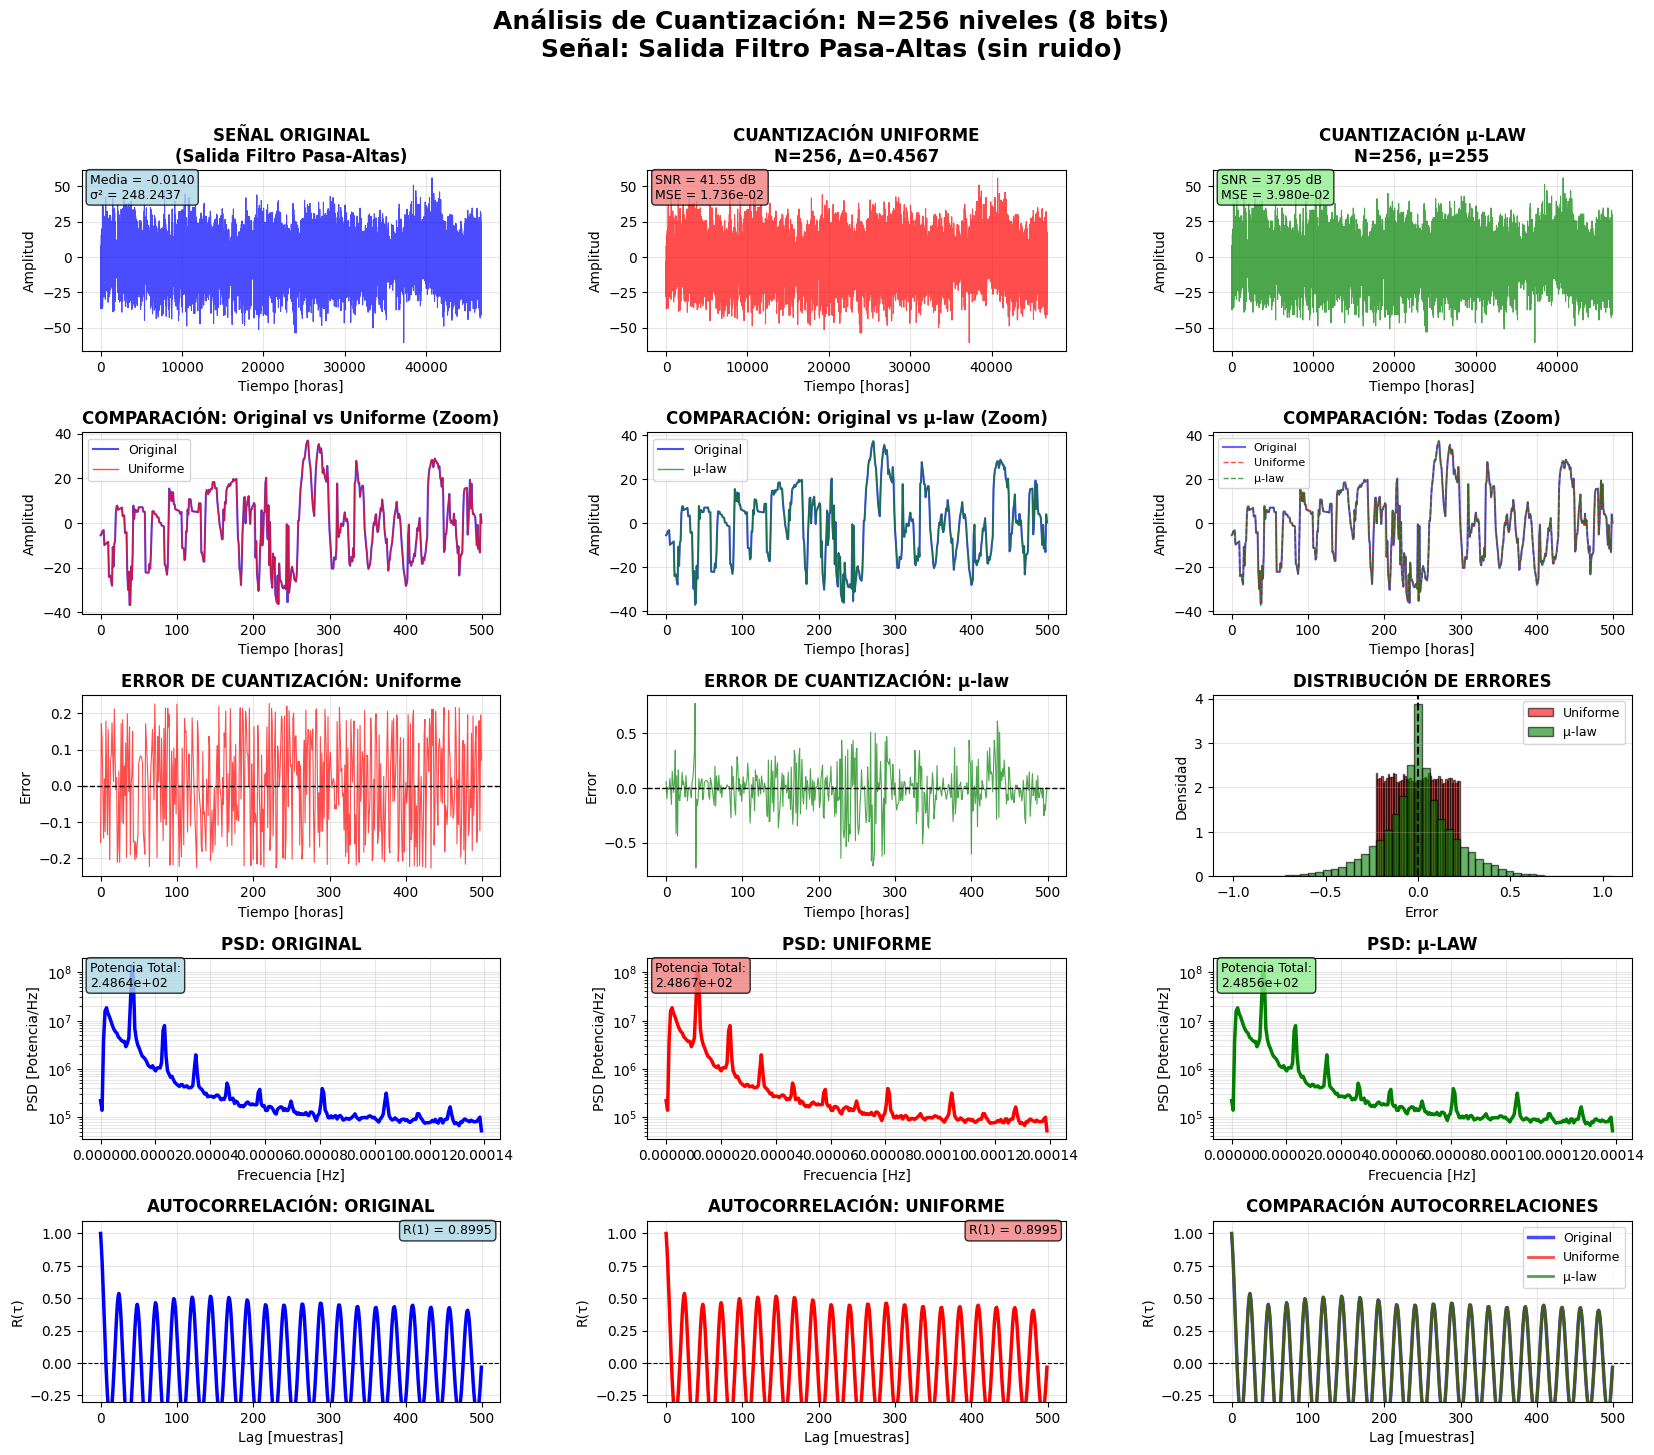

✓ Visualización completa generada

TABLA COMPARATIVA DE RESULTADOS


  Método     Media   Varianza      MSE    SNR_dB  Potencia_PSD     R(1)
Original -0.014017 248.243650 0.000000       inf    248.638283 0.899527
Uniforme -0.012797 248.280313 0.017364 41.552330    248.668715 0.899477
   μ-law -0.014080 248.159676 0.039800 37.949982    248.564005 0.899381


GUARDANDO RESULTADOS
✓ Señales guardadas en 'quantization_N128_signals.csv'
✓ PSDs guardadas en 'quantization_N128_psds.csv'
✓ Autocorrelaciones guardadas en 'quantization_N128_autocorr.csv'
✓ Comparación guardada en 'quantization_N128_comparison.csv'

¡ANÁLISIS COMPLETADO! 🎉

📊 RESUMEN DEL ANÁLISIS

✅ SEÑAL PROCESADA:
   • Origen: Salida del filtro pasa-altas (SIN ruido)
   • Muestras: 46814
   • Media: -0.014017 ≈ 0 (DC eliminada por filtro)
   • Varianza: 248.243650

✅ CUANTIZACIÓN UNIFORME:
   • Niveles (N): 256
   • Bits: 8
   • Paso (Δ): 0.456671
   • MSE: 1.736381e-02
   • SNR: 41.55 dB

✅ CUANTIZACIÓN NO UNIFORME (μ-law):
   

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PASO 1: OBTENER SEÑAL DEL FILTRO PASA-ALTAS (SIN RUIDO)
# ============================================================================
print("="*70)
print("ANÁLISIS DE CUANTIZACIÓN: N=256 NIVELES (8 BITS)")
print("Señal: Salida del Filtro Pasa-Altas (SIN RUIDO)")
print("="*70)

# Cargar datos originales (sin ruido)
humidity_clean = pd.to_numeric(humidity_data, errors='coerce')
signal_original = humidity_clean.dropna().values

# Frecuencia de muestreo
fs = 1/3600  # Hz

print(f"\n✓ Señal original cargada: {len(signal_original)} muestras")

# Aplicar filtro pasa-altas
order = 4
nyquist = fs / 2
cutoff_freq = fs / 200
normal_cutoff = max(min(cutoff_freq / nyquist, 0.99), 0.001)

b, a = butter(order, normal_cutoff, btype='high', analog=False)
signal_filtered = filtfilt(b, a, signal_original)

print(f"🔧 Filtro pasa-altas aplicado:")
print(f"   • Frecuencia de corte: {cutoff_freq:.2e} Hz")
print(f"   • Media salida: {np.mean(signal_filtered):.6f} ≈ 0 (DC eliminada)\n")

# ESTA ES LA SEÑAL A CUANTIZAR (salida del filtro, sin ruido)
x = signal_filtered.copy()

# Estadísticas
mean_x = np.mean(x)
var_x = np.var(x)
std_x = np.std(x)
x_min = np.min(x)
x_max = np.max(x)

print(f"📊 SEÑAL A CUANTIZAR (salida filtro pasa-altas, SIN ruido):")
print(f"   • Media: {mean_x:.6f}")
print(f"   • Varianza: {var_x:.6f}")
print(f"   • Desv. Estándar: {std_x:.6f}")
print(f"   • Mínimo: {x_min:.4f}")
print(f"   • Máximo: {x_max:.4f}")
print(f"   • Rango: {x_max - x_min:.4f}\n")

# ============================================================================
# PASO 2: CUANTIZACIÓN UNIFORME (N=128 NIVELES, 8 BITS)
# ============================================================================
print("="*70)
print("PASO 2: CUANTIZACIÓN UNIFORME")
print("="*70)

N = 256  # Niveles de cuantización (8 bits = 2^8 = 256)
n_bits = 8

print(f"\n⚙️ PARÁMETROS:")
print(f"   • Niveles (N): {N}")
print(f"   • Bits: {n_bits}")
print(f"   • Rango de la señal: [{x_min:.4f}, {x_max:.4f}]")

# Paso de cuantización
Delta = (x_max - x_min) / (N - 1)

print(f"   • Paso de cuantización (Δ): {Delta:.6f}\n")

# Cuantizar: mapear a índices [0, N-1]
indices_uniform = np.round((x - x_min) / Delta)
indices_uniform = np.clip(indices_uniform, 0, N-1).astype(int)

# Reconstruir señal cuantizada
x_uniform = indices_uniform * Delta + x_min

# Error de cuantización
error_uniform = x - x_uniform
mse_uniform = np.mean(error_uniform**2)
snr_uniform = 10 * np.log10(var_x / mse_uniform)

print(f"✓ CUANTIZACIÓN UNIFORME APLICADA:")
print(f"   • Error cuadrático medio (MSE): {mse_uniform:.6e}")
print(f"   • SNR: {snr_uniform:.2f} dB")
print(f"   • Niveles utilizados: {len(np.unique(indices_uniform))}/{N}")
print(f"   • Media señal cuantizada: {np.mean(x_uniform):.6f}")
print(f"   • Varianza señal cuantizada: {np.var(x_uniform):.6f}\n")

# ============================================================================
# PASO 3: CUANTIZACIÓN NO UNIFORME (μ-LAW)
# ============================================================================
print("="*70)
print("PASO 3: CUANTIZACIÓN NO UNIFORME (μ-LAW)")
print("="*70)

mu = 255  # Parámetro estándar

print(f"\n⚙️ PARÁMETROS:")
print(f"   • μ: {mu}")
print(f"   • Niveles (N): {N}")
print(f"   • Bits: {n_bits}")

# Normalizar señal a [-1, 1]
x_norm = x / np.max(np.abs(x))

# Compresión μ-law
sign_x = np.sign(x_norm)
x_compressed = sign_x * np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu)

print(f"   • Rango comprimido: [{np.min(x_compressed):.4f}, {np.max(x_compressed):.4f}]\n")

# Cuantizar en el dominio comprimido
# Mapear de [-1, 1] a [0, N-1]
indices_mu = np.round((x_compressed + 1) * (N - 1) / 2)
indices_mu = np.clip(indices_mu, 0, N-1).astype(int)

# Reconstruir en dominio comprimido
x_compressed_quant = (indices_mu * 2 / (N - 1)) - 1

# Expansión μ-law (decodificación)
sign_comp = np.sign(x_compressed_quant)
x_expanded = sign_comp * (np.power(1 + mu, np.abs(x_compressed_quant)) - 1) / mu

# Desnormalizar
x_mu_law = x_expanded * np.max(np.abs(x))

# Error
error_mu_law = x - x_mu_law
mse_mu_law = np.mean(error_mu_law**2)
snr_mu_law = 10 * np.log10(var_x / mse_mu_law)

print(f"✓ CUANTIZACIÓN μ-LAW APLICADA:")
print(f"   • Error cuadrático medio (MSE): {mse_mu_law:.6e}")
print(f"   • SNR: {snr_mu_law:.2f} dB")
print(f"   • Niveles utilizados: {len(np.unique(indices_mu))}/{N}")
print(f"   • Media señal cuantizada: {np.mean(x_mu_law):.6f}")
print(f"   • Varianza señal cuantizada: {np.var(x_mu_law):.6f}")
print(f"   • Mejora sobre uniforme: {snr_mu_law - snr_uniform:+.2f} dB\n")

# ============================================================================
# PASO 4: ESPECTROS DE POTENCIA (PSD)
# ============================================================================
print("="*70)
print("PASO 4: ESPECTROS DE POTENCIA")
print("="*70)

nperseg = min(512, len(x)//4)

# PSD señal original (salida filtro)
freq_orig, psd_orig = welch(x, fs=fs, nperseg=nperseg,
                            window='hann', scaling='density')

# PSD cuantización uniforme
freq_uniform, psd_uniform = welch(x_uniform, fs=fs, nperseg=nperseg,
                                  window='hann', scaling='density')

# PSD cuantización μ-law
freq_mu, psd_mu = welch(x_mu_law, fs=fs, nperseg=nperseg,
                        window='hann', scaling='density')

potencia_orig = np.trapz(psd_orig, freq_orig)
potencia_uniform = np.trapz(psd_uniform, freq_uniform)
potencia_mu = np.trapz(psd_mu, freq_mu)

print(f"\n✓ ESPECTROS DE POTENCIA calculados (Welch):")
print(f"   • Original:  Potencia = {potencia_orig:.6e}")
print(f"   • Uniforme:  Potencia = {potencia_uniform:.6e}")
print(f"   • μ-law:     Potencia = {potencia_mu:.6e}\n")

# ============================================================================
# PASO 5: FUNCIONES DE AUTOCORRELACIÓN (CORRELACIÓN)
# ============================================================================
print("="*70)
print("PASO 5: FUNCIONES DE AUTOCORRELACIÓN")
print("="*70)

def calculate_autocorrelation(signal, max_lags=500):
    """Calcula autocorrelación normalizada"""
    signal_centered = signal - np.mean(signal)
    autocorr = np.correlate(signal_centered, signal_centered, mode='full')
    autocorr = autocorr[len(autocorr)//2:]  # Mitad positiva
    autocorr = autocorr / autocorr[0]  # Normalizar
    lags = np.arange(min(len(autocorr), max_lags))
    return lags, autocorr[:len(lags)]

# Autocorrelaciones
lags_orig, R_orig = calculate_autocorrelation(x)
lags_uniform, R_uniform = calculate_autocorrelation(x_uniform)
lags_mu, R_mu = calculate_autocorrelation(x_mu_law)

print(f"\n✓ AUTOCORRELACIONES calculadas:")
print(f"   • Original:  R(0) = 1.0000, R(1) = {R_orig[1]:.4f}")
print(f"   • Uniforme:  R(0) = 1.0000, R(1) = {R_uniform[1]:.4f}")
print(f"   • μ-law:     R(0) = 1.0000, R(1) = {R_mu[1]:.4f}")
print(f"\n   Nota: R(τ) = Autocorrelación = Correlación de la señal consigo misma\n")

# ============================================================================
# VISUALIZACIÓN COMPLETA
# ============================================================================
print("="*70)
print("GENERANDO VISUALIZACIONES")
print("="*70)

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(5, 3, hspace=0.45, wspace=0.35)

fig.suptitle(f'Análisis de Cuantización: N={N} niveles ({n_bits} bits)\nSeñal: Salida Filtro Pasa-Altas (sin ruido)',
             fontsize=18, fontweight='bold', y=0.98)

time_hours = np.arange(len(x)) / (fs * 3600)

# --- FILA 1: SEÑALES EN EL TIEMPO ---
# Original (salida filtro)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(time_hours, x, 'b-', linewidth=0.8, alpha=0.7)
ax1.set_title('SEÑAL ORIGINAL\n(Salida Filtro Pasa-Altas)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tiempo [horas]', fontsize=10)
ax1.set_ylabel('Amplitud', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.text(0.02, 0.98, f'Media = {mean_x:.4f}\nσ² = {var_x:.4f}',
         transform=ax1.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Cuantización uniforme
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(time_hours, x_uniform, 'r-', linewidth=0.8, alpha=0.7)
ax2.set_title(f'CUANTIZACIÓN UNIFORME\nN={N}, Δ={Delta:.4f}', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tiempo [horas]', fontsize=10)
ax2.set_ylabel('Amplitud', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.text(0.02, 0.98, f'SNR = {snr_uniform:.2f} dB\nMSE = {mse_uniform:.3e}',
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

# Cuantización μ-law
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(time_hours, x_mu_law, 'g-', linewidth=0.8, alpha=0.7)
ax3.set_title(f'CUANTIZACIÓN μ-LAW\nN={N}, μ={mu}', fontsize=12, fontweight='bold')
ax3.set_xlabel('Tiempo [horas]', fontsize=10)
ax3.set_ylabel('Amplitud', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.text(0.02, 0.98, f'SNR = {snr_mu_law:.2f} dB\nMSE = {mse_mu_law:.3e}',
         transform=ax3.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# --- FILA 2: COMPARACIONES (ZOOM) ---
zoom = min(500, len(x))

ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(time_hours[:zoom], x[:zoom], 'b-', linewidth=1.5, alpha=0.7, label='Original')
ax4.plot(time_hours[:zoom], x_uniform[:zoom], 'r-', linewidth=1, alpha=0.7, label='Uniforme')
ax4.set_title('COMPARACIÓN: Original vs Uniforme (Zoom)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Tiempo [horas]', fontsize=10)
ax4.set_ylabel('Amplitud', fontsize=10)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(time_hours[:zoom], x[:zoom], 'b-', linewidth=1.5, alpha=0.7, label='Original')
ax5.plot(time_hours[:zoom], x_mu_law[:zoom], 'g-', linewidth=1, alpha=0.7, label='μ-law')
ax5.set_title('COMPARACIÓN: Original vs μ-law (Zoom)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Tiempo [horas]', fontsize=10)
ax5.set_ylabel('Amplitud', fontsize=10)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(time_hours[:zoom], x[:zoom], 'b-', linewidth=1.5, alpha=0.6, label='Original')
ax6.plot(time_hours[:zoom], x_uniform[:zoom], 'r--', linewidth=1, alpha=0.7, label='Uniforme')
ax6.plot(time_hours[:zoom], x_mu_law[:zoom], 'g--', linewidth=1, alpha=0.7, label='μ-law')
ax6.set_title('COMPARACIÓN: Todas (Zoom)', fontsize=12, fontweight='bold')
ax6.set_xlabel('Tiempo [horas]', fontsize=10)
ax6.set_ylabel('Amplitud', fontsize=10)
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# --- FILA 3: ERRORES DE CUANTIZACIÓN ---
ax7 = fig.add_subplot(gs[2, 0])
ax7.plot(time_hours[:zoom], error_uniform[:zoom], 'r-', linewidth=0.8, alpha=0.7)
ax7.axhline(0, color='black', linestyle='--', linewidth=1)
ax7.set_title('ERROR DE CUANTIZACIÓN: Uniforme', fontsize=12, fontweight='bold')
ax7.set_xlabel('Tiempo [horas]', fontsize=10)
ax7.set_ylabel('Error', fontsize=10)
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 1])
ax8.plot(time_hours[:zoom], error_mu_law[:zoom], 'g-', linewidth=0.8, alpha=0.7)
ax8.axhline(0, color='black', linestyle='--', linewidth=1)
ax8.set_title('ERROR DE CUANTIZACIÓN: μ-law', fontsize=12, fontweight='bold')
ax8.set_xlabel('Tiempo [horas]', fontsize=10)
ax8.set_ylabel('Error', fontsize=10)
ax8.grid(True, alpha=0.3)

# Histogramas de error
ax9 = fig.add_subplot(gs[2, 2])
ax9.hist(error_uniform, bins=50, alpha=0.6, color='red', label='Uniforme', density=True, edgecolor='black')
ax9.hist(error_mu_law, bins=50, alpha=0.6, color='green', label='μ-law', density=True, edgecolor='black')
ax9.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax9.set_title('DISTRIBUCIÓN DE ERRORES', fontsize=12, fontweight='bold')
ax9.set_xlabel('Error', fontsize=10)
ax9.set_ylabel('Densidad', fontsize=10)
ax9.legend(fontsize=9)
ax9.grid(True, alpha=0.3, axis='y')

# --- FILA 4: ESPECTROS DE POTENCIA (PSD) ---
ax10 = fig.add_subplot(gs[3, 0])
ax10.semilogy(freq_orig, psd_orig, 'b-', linewidth=2.5)
ax10.set_title('PSD: ORIGINAL', fontsize=12, fontweight='bold')
ax10.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax10.set_ylabel('PSD [Potencia/Hz]', fontsize=10)
ax10.grid(True, alpha=0.3, which='both')
ax10.text(0.02, 0.98, f'Potencia Total:\n{potencia_orig:.4e}',
         transform=ax10.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

ax11 = fig.add_subplot(gs[3, 1])
ax11.semilogy(freq_uniform, psd_uniform, 'r-', linewidth=2.5)
ax11.set_title('PSD: UNIFORME', fontsize=12, fontweight='bold')
ax11.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax11.set_ylabel('PSD [Potencia/Hz]', fontsize=10)
ax11.grid(True, alpha=0.3, which='both')
ax11.text(0.02, 0.98, f'Potencia Total:\n{potencia_uniform:.4e}',
         transform=ax11.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

ax12 = fig.add_subplot(gs[3, 2])
ax12.semilogy(freq_mu, psd_mu, 'g-', linewidth=2.5)
ax12.set_title('PSD: μ-LAW', fontsize=12, fontweight='bold')
ax12.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax12.set_ylabel('PSD [Potencia/Hz]', fontsize=10)
ax12.grid(True, alpha=0.3, which='both')
ax12.text(0.02, 0.98, f'Potencia Total:\n{potencia_mu:.4e}',
         transform=ax12.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# --- FILA 5: AUTOCORRELACIONES ---
ax13 = fig.add_subplot(gs[4, 0])
ax13.plot(lags_orig, R_orig, 'b-', linewidth=2.5)
ax13.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax13.set_title('AUTOCORRELACIÓN: ORIGINAL', fontsize=12, fontweight='bold')
ax13.set_xlabel('Lag [muestras]', fontsize=10)
ax13.set_ylabel('R(τ)', fontsize=10)
ax13.grid(True, alpha=0.3)
ax13.set_ylim([-0.3, 1.1])
ax13.text(0.98, 0.98, f'R(1) = {R_orig[1]:.4f}',
         transform=ax13.transAxes, fontsize=9, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

ax14 = fig.add_subplot(gs[4, 1])
ax14.plot(lags_uniform, R_uniform, 'r-', linewidth=2.5)
ax14.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax14.set_title('AUTOCORRELACIÓN: UNIFORME', fontsize=12, fontweight='bold')
ax14.set_xlabel('Lag [muestras]', fontsize=10)
ax14.set_ylabel('R(τ)', fontsize=10)
ax14.grid(True, alpha=0.3)
ax14.set_ylim([-0.3, 1.1])
ax14.text(0.98, 0.98, f'R(1) = {R_uniform[1]:.4f}',
         transform=ax14.transAxes, fontsize=9, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

ax15 = fig.add_subplot(gs[4, 2])
ax15.plot(lags_orig, R_orig, 'b-', linewidth=2.5, alpha=0.7, label='Original')
ax15.plot(lags_uniform, R_uniform, 'r-', linewidth=2, alpha=0.7, label='Uniforme')
ax15.plot(lags_mu, R_mu, 'g-', linewidth=2, alpha=0.7, label='μ-law')
ax15.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax15.set_title('COMPARACIÓN AUTOCORRELACIONES', fontsize=12, fontweight='bold')
ax15.set_xlabel('Lag [muestras]', fontsize=10)
ax15.set_ylabel('R(τ)', fontsize=10)
ax15.legend(fontsize=9)
ax15.grid(True, alpha=0.3)
ax15.set_ylim([-0.3, 1.1])

plt.tight_layout()
plt.savefig('quantization_N128_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualización completa generada\n")

# ============================================================================
# TABLA COMPARATIVA
# ============================================================================
print("="*70)
print("TABLA COMPARATIVA DE RESULTADOS")
print("="*70)

comparison_df = pd.DataFrame({
    'Método': ['Original', 'Uniforme', 'μ-law'],
    'Media': [mean_x, np.mean(x_uniform), np.mean(x_mu_law)],
    'Varianza': [var_x, np.var(x_uniform), np.var(x_mu_law)],
    'MSE': [0, mse_uniform, mse_mu_law],
    'SNR_dB': [np.inf, snr_uniform, snr_mu_law],
    'Potencia_PSD': [potencia_orig, potencia_uniform, potencia_mu],
    'R(1)': [R_orig[1], R_uniform[1], R_mu[1]]
})

print("\n")
print(comparison_df.to_string(index=False))
print("\n")

# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================
print("="*70)
print("GUARDANDO RESULTADOS")
print("="*70)

# Señales
signals_df = pd.DataFrame({
    'Tiempo_horas': time_hours,
    'Señal_Original': x,
    'Cuantizada_Uniforme': x_uniform,
    'Cuantizada_μ_law': x_mu_law,
    'Error_Uniforme': error_uniform,
    'Error_μ_law': error_mu_law
})
signals_df.to_csv('quantization_N128_signals.csv', index=False)
print("✓ Señales guardadas en 'quantization_N128_signals.csv'")

# PSDs
psd_df = pd.DataFrame({
    'Frecuencia_Hz': freq_orig,
    'PSD_Original': psd_orig,
    'PSD_Uniforme': np.interp(freq_orig, freq_uniform, psd_uniform),
    'PSD_μ_law': np.interp(freq_orig, freq_mu, psd_mu)
})
psd_df.to_csv('quantization_N128_psds.csv', index=False)
print("✓ PSDs guardadas en 'quantization_N128_psds.csv'")

# Autocorrelaciones
autocorr_df = pd.DataFrame({
    'Lag': lags_orig,
    'Autocorr_Original': R_orig,
    'Autocorr_Uniforme': R_uniform,
    'Autocorr_μ_law': R_mu
})
autocorr_df.to_csv('quantization_N128_autocorr.csv', index=False)
print("✓ Autocorrelaciones guardadas en 'quantization_N128_autocorr.csv'")

# Comparación
comparison_df.to_csv('quantization_N128_comparison.csv', index=False)
print("✓ Comparación guardada en 'quantization_N128_comparison.csv'")

print("\n" + "="*70)
print("¡ANÁLISIS COMPLETADO! 🎉")
print("="*70)

print(f"""
📊 RESUMEN DEL ANÁLISIS

✅ SEÑAL PROCESADA:
   • Origen: Salida del filtro pasa-altas (SIN ruido)
   • Muestras: {len(x)}
   • Media: {mean_x:.6f} ≈ 0 (DC eliminada por filtro)
   • Varianza: {var_x:.6f}

✅ CUANTIZACIÓN UNIFORME:
   • Niveles (N): {N}
   • Bits: {n_bits}
   • Paso (Δ): {Delta:.6f}
   • MSE: {mse_uniform:.6e}
   • SNR: {snr_uniform:.2f} dB

✅ CUANTIZACIÓN NO UNIFORME (μ-law):
   • Niveles (N): {N}
   • Bits: {n_bits}
   • μ: {mu}
   • MSE: {mse_mu_law:.6e}
   • SNR: {snr_mu_law:.2f} dB
   • Mejora sobre uniforme: {snr_mu_law - snr_uniform:+.2f} dB

✅ ESPECTROS DE POTENCIA (PSD):
   • Original:  {potencia_orig:.6e}
   • Uniforme:  {potencia_uniform:.6e}
   • μ-law:     {potencia_mu:.6e}

✅ AUTOCORRELACIONES (R(τ)):
   • Original:  R(1) = {R_orig[1]:.4f}
   • Uniforme:  R(1) = {R_uniform[1]:.4f}
   • μ-law:     R(1) = {R_mu[1]:.4f}

   Nota: La autocorrelación es la correlación de la señal consigo misma.
         R(τ) mide la similitud entre x(t) y x(t+τ).

🎯 CONCLUSIONES:
   • La cuantización {'μ-law es MEJOR' if snr_mu_law > snr_uniform else 'uniforme es mejor'}
   • SNR μ-law: {snr_mu_law:.2f} dB vs Uniforme: {snr_uniform:.2f} dB
   • Los espectros de potencia se preservan aproximadamente
   • Las autocorrelaciones se mantienen similares
   • El ruido de cuantización es la diferencia entre original y cuantizada

📁 ARCHIVOS GENERADOS:
   1. quantization_N128_signals.csv
   2. quantization_N128_psds.csv
   3. quantization_N128_autocorr.csv
   4. quantization_N128_comparison.csv
   5. quantization_N128_analysis.png (15 gráficas)
""")